# Teste com banco de dados pequeno

⚙️ Processando Features...

📊 RESULTADOS DA AVALIAÇÃO:
Acurácia: 99.00%
F1-Score: 97.44%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        80
           1       1.00      0.95      0.97        20

    accuracy                           0.99       100
   macro avg       0.99      0.97      0.98       100
weighted avg       0.99      0.99      0.99       100



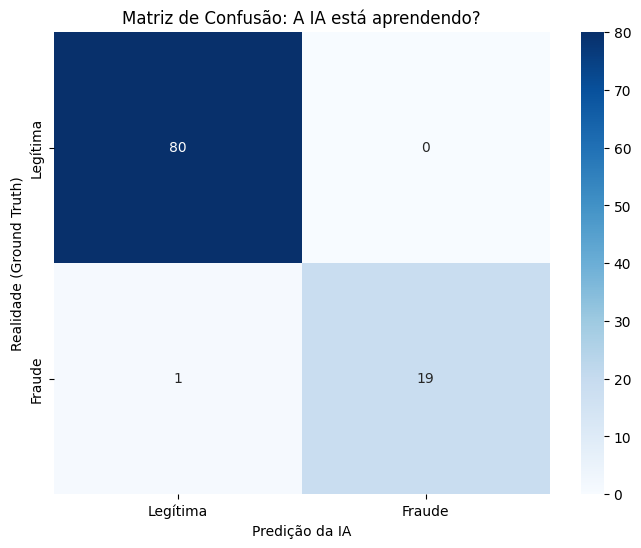

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

# 1. CARREGAR OS DADOS
# Se estiver no Kaggle, faça o upload do arquivo ou use o caminho correto
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/transacoes-bancarias/transacoes_bancarias.csv')
df['data_hora'] = pd.to_datetime(df['data_hora'])
df = df.sort_values(['cliente_id', 'data_hora'])

# 2. ENGENHARIA DE FEATURES (Preparando os dados para o Score)
print("⚙️ Processando Features...")

# Perfil do cliente (Média de gastos)
media_gastos = df.groupby('cliente_id')['valor'].mean().to_dict()
df['media_cliente'] = df['cliente_id'].map(media_gastos)

# Valor Relativo
df['valor_relativo'] = df['valor'] / df['media_cliente']

# Diferença de País
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)

# Simulação de Velocidade de Viagem 
df['velocidade_viagem'] = np.where(df['pais_diferente'] == 1, 900, 0)

# Transação Noturna (22h às 06h)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)

# 3. SISTEMA DE SCORE 
def calcular_score(row):
    score = 0
    if row['pais_diferente'] == 1: score += 4
    if row['velocidade_viagem'] > 800: score += 5
    if row['valor_relativo'] > 3: score += 3
    if row['transacao_noturna'] == 1: score += 1
    if row['falha_autenticacao'] == 1: score += 5
    if row['tipo_autenticacao'] in ['biometria', '2FA']: score -= 3
    return score

df['score_final'] = df.apply(calcular_score, axis=1)

# 4. CLASSIFICAÇÃO (Threshold)
# Vamos usar o seu threshold de 10
df['predicao'] = df['score_final'].apply(lambda x: 1 if x >= 10 else 0)

# 5. AVALIAÇÃO DE PERFORMANCE
print("\n📊 RESULTADOS DA AVALIAÇÃO:")
acc = accuracy_score(df['fraude'], df['predicao'])
f1 = f1_score(df['fraude'], df['predicao'])

print(f"Acurácia: {acc:.2%}")
print(f"F1-Score: {f1:.2%}")
print("\nRelatório de Classificação:")
print(classification_report(df['fraude'], df['predicao']))

# 6. MATRIZ DE CONFUSÃO (Visualização)
plt.figure(figsize=(8,6))
cm = confusion_matrix(df['fraude'], df['predicao'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legítima', 'Fraude'], 
            yticklabels=['Legítima', 'Fraude'])
plt.xlabel('Predição da IA')
plt.ylabel('Realidade (Ground Truth)')
plt.title('Matriz de Confusão: A IA está aprendendo?')
plt.show()

# Teste com transações noturnas e sem autenticação 

⚖️ Calculando Heurística...
🧠 Treinando a IA com 14000 transações...

📊 RELATÓRIO DE PERFORMANCE FINAL
Acurácia Geral: 100.00%
Precisão:       100.00%
Recall:         100.00%
F1-Score:       100.00%
----------------------------------------

Relatório Detalhado do Scikit-Learn:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2850
           1       1.00      1.00      1.00       150

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



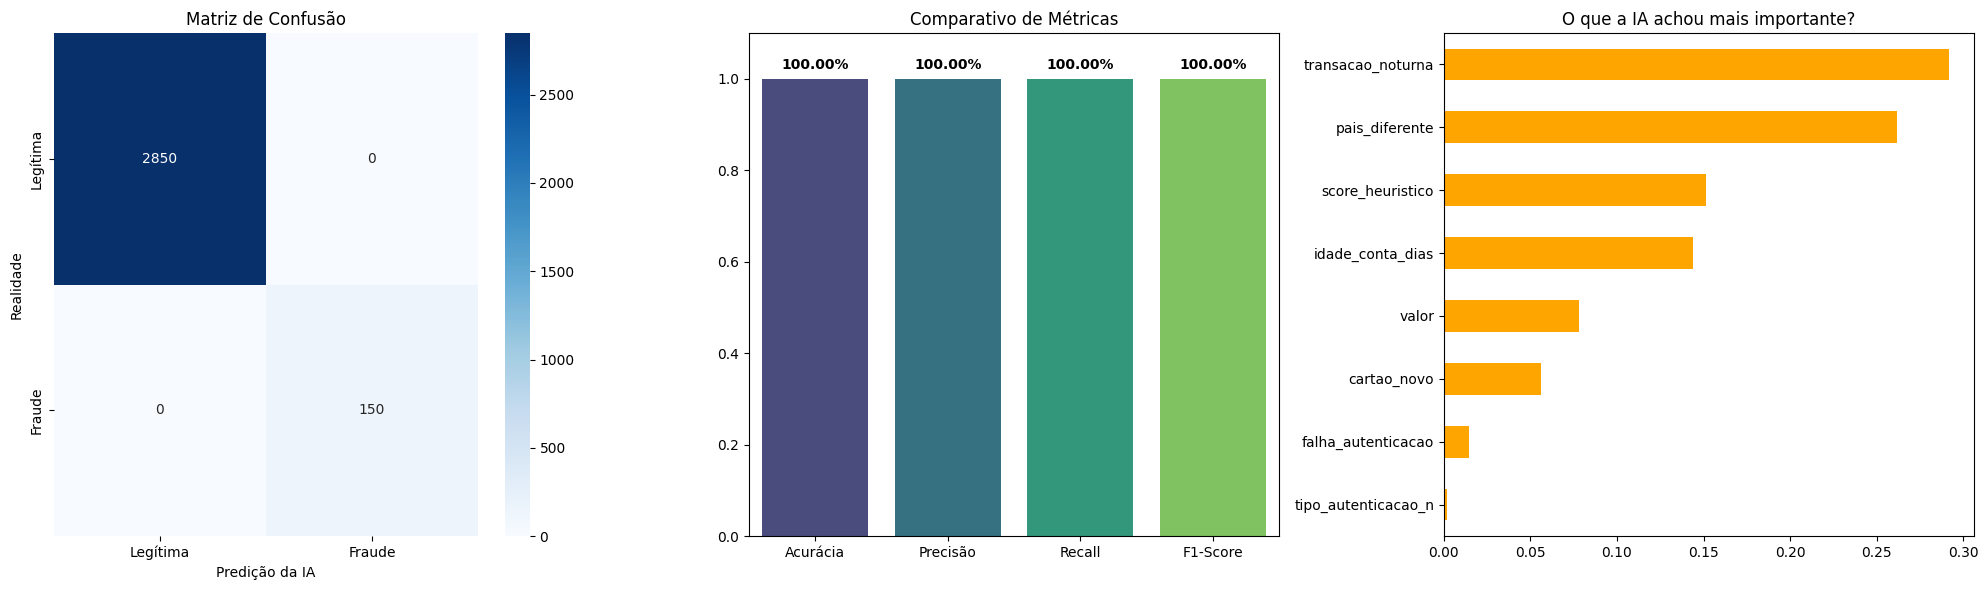

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)

# ==========================================
# 1. CARREGAMENTO DOS DADOS
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/fraudes/banco_dados_fraude_20k.csv')

df['data_hora'] = pd.to_datetime(df['data_hora'])

# ==========================================
# 2. HEURÍSTICA (Sua Inteligência de Negócio)
# ==========================================
def aplicar_heuristica(row):
    score = 0
    # Regra de Localização
    if row['pais_transacao'] != row['pais_cliente']: score += 4
    # Regra de Autenticação
    if row['falha_autenticacao'] > 0: score += 5
    if row['tipo_autenticacao'] in ['biometria', '2FA']: score -= 3
    # Regra de Idade da Conta
    if row['idade_conta_dias'] < 30: score += 2
    return score

print("⚖️ Calculando Heurística...")
df['score_heuristico'] = df.apply(aplicar_heuristica, axis=1)

# ==========================================
# 3. ENGENHARIA DE FEATURES (Preparação)
# ==========================================
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3})

# ==========================================
# 4. DIVISÃO DO DATASET (70% Treino | 15% Val, 15% Teste)
# ==========================================
features = ['valor', 'pais_diferente', 'transacao_noturna', 'tipo_autenticacao_n', 
            'falha_autenticacao', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# ==========================================
# 5. TREINAMENTO DO MODELO
# ==========================================
print(f"🧠 Treinando a IA com {len(X_train)} transações...")
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# ==========================================
# 6. AVALIAÇÃO FINAL (CÁLCULO DE MÉTRICAS)
# ==========================================
y_pred = modelo.predict(X_test)

# Cálculos Individuais
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*40)
print("📊 RELATÓRIO DE PERFORMANCE FINAL")
print("="*40)
print(f"Acurácia Geral: {acuracia:.2%}")
print(f"Precisão:       {precisao:.2%}")
print(f"Recall:         {recall:.2%}")
print(f"F1-Score:       {f1:.2%}")
print("-" * 40)
print("\nRelatório Detalhado do Scikit-Learn:")
print(classification_report(y_test, y_pred))

# ==========================================
# 7. VISUALIZAÇÃO DOS RESULTADOS
# ==========================================
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# 1. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
ax[0].set_title('Matriz de Confusão')
ax[0].set_xlabel('Predição da IA')
ax[0].set_ylabel('Realidade')

# 2. Gráfico de Barras das Métricas
metricas_nomes = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores = [acuracia, precisao, recall, f1]
sns.barplot(x=metricas_nomes, y=valores, hue=metricas_nomes, palette='viridis', ax=ax[1], legend=False)

ax[1].set_ylim(0, 1.1)
ax[1].set_title('Comparativo de Métricas')
for i, v in enumerate(valores):
    ax[1].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

# 3. Importância das Variáveis
importancias = pd.Series(modelo.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', ax=ax[2], color='orange')
ax[2].set_title('O que a IA achou mais importante?')

plt.tight_layout()
plt.show()

# Teste com banco de dados com fraudes mais sensíveis

⚖️ Calculando Heurística...
🧠 Treinando a IA com 14000 transações...

📊 RELATÓRIO DE PERFORMANCE FINAL
Acurácia Geral: 100.00%
Precisão:       100.00%
Recall:         100.00%
F1-Score:       100.00%
----------------------------------------

Relatório Detalhado do Scikit-Learn:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2850
           1       1.00      1.00      1.00       150

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



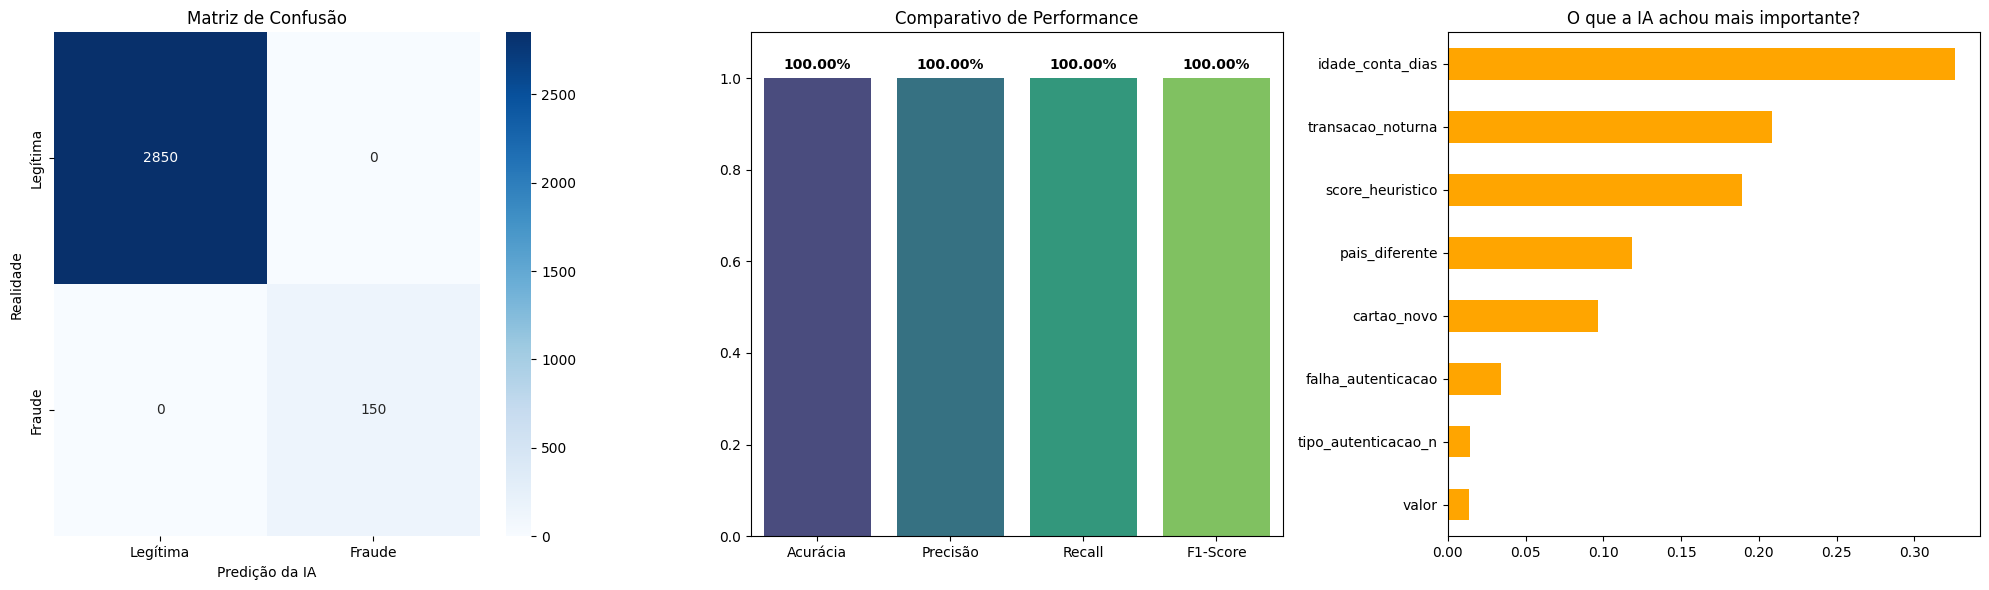

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)

# ==========================================
# 1. CARREGAMENTO DOS DADOS
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancosensivel/banco_dados_fraude_sensivel_20k.csv')

df['data_hora'] = pd.to_datetime(df['data_hora'])

# ==========================================
# 2. HEURÍSTICA 
# ==========================================
def aplicar_heuristica(row):
    score = 0
    # Regra de Localização
    if row['pais_transacao'] != row['pais_cliente']: score += 4
    # Regra de Autenticação
    if row['falha_autenticacao'] > 0: score += 5
    if row['tipo_autenticacao'] in ['biometria', '2FA']: score -= 3
    # Regra de Idade da Conta
    if row['idade_conta_dias'] < 30: score += 2
    return score

print("⚖️ Calculando Heurística...")
df['score_heuristico'] = df.apply(aplicar_heuristica, axis=1)

# ==========================================
# 3. ENGENHARIA DE FEATURES (Preparação)
# ==========================================
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3})

# ==========================================
# 4. DIVISÃO DO DATASET (Treino, Validação e Teste)
# ==========================================
features = ['valor', 'pais_diferente', 'transacao_noturna', 'tipo_autenticacao_n', 
            'falha_autenticacao', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# ==========================================
# 5. TREINAMENTO DO MODELO
# ==========================================
print(f"🧠 Treinando a IA com {len(X_train)} transações...")
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# ==========================================
# 6. AVALIAÇÃO FINAL (MÉTRICAS DETALHADAS)
# ==========================================
y_pred = modelo.predict(X_test)

# Cálculos Individuais
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*40)
print("📊 RELATÓRIO DE PERFORMANCE FINAL")
print("="*40)
print(f"Acurácia Geral: {acuracia:.2%}")
print(f"Precisão:       {precisao:.2%}")
print(f"Recall:         {recall:.2%}")
print(f"F1-Score:       {f1:.2%}")
print("-" * 40)
print("\nRelatório Detalhado do Scikit-Learn:")
print(classification_report(y_test, y_pred))

# ==========================================
# 7. VISUALIZAÇÃO DOS RESULTADOS
# ==========================================
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# 1. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
ax[0].set_title('Matriz de Confusão')
ax[0].set_xlabel('Predição da IA')
ax[0].set_ylabel('Realidade')

# 2. Gráfico de Barras das Métricas 
metricas_nomes = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores = [acuracia, precisao, recall, f1]
sns.barplot(x=metricas_nomes, y=valores, hue=metricas_nomes, palette='viridis', ax=ax[1], legend=False)
ax[1].set_ylim(0, 1.1)
ax[1].set_title('Comparativo de Performance')
for i, v in enumerate(valores):
    ax[1].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

# 3. Importância das Variáveis
importancias = pd.Series(modelo.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', ax=ax[2], color='orange')
ax[2].set_title('O que a IA achou mais importante?')

plt.tight_layout()
plt.show()

# Remoção da variável idade_conta_dias para ver se ela ainda consegue manter os 100% 

⚖️ Calculando Heurística (Sem Idade)...
🧠 Round 3: Treinando IA sem a variável de Idade da Conta...

📊 PERFORMANCE ROUND 3 (TESTE DE ESTRESSE)
Acurácia Geral: 99.33%
Precisão:       93.33%
Recall:         93.33%
F1-Score:       93.33%
----------------------------------------

Relatório Detalhado:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2850
           1       0.93      0.93      0.93       150

    accuracy                           0.99      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.99      0.99      0.99      3000



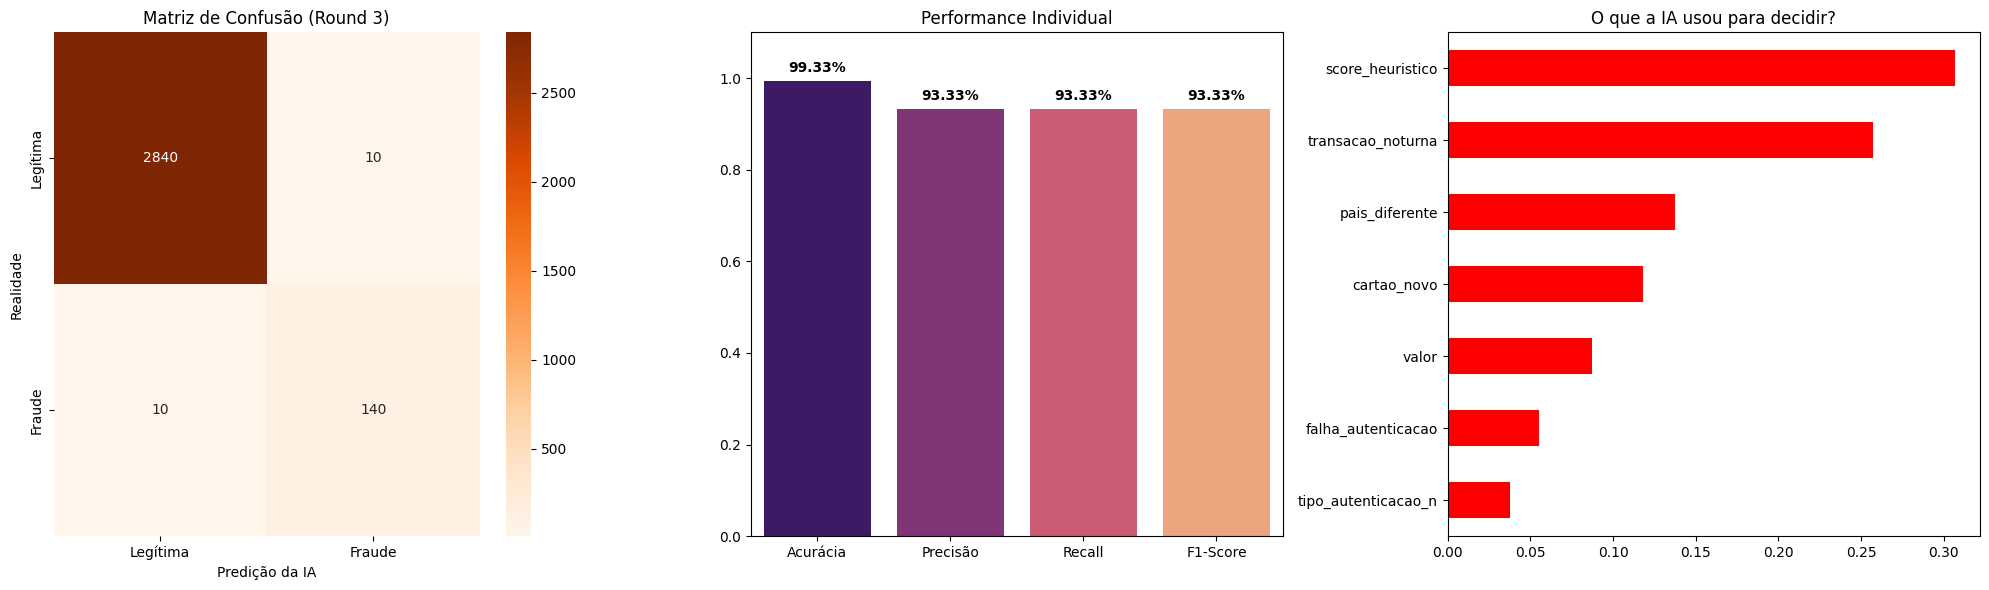

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)

# ==========================================
# 1. CARREGAMENTO DOS DADOS
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancosensivel/banco_dados_fraude_sensivel_20k.csv')
df['data_hora'] = pd.to_datetime(df['data_hora'])

# ==========================================
# 2. HEURÍSTICA AJUSTADA (Sem Idade da Conta)
# ==========================================
def aplicar_heuristica_sem_idade(row):
    score = 0
    if row['pais_transacao'] != row['pais_cliente']: score += 4
    if row['falha_autenticacao'] > 0: score += 5
    if row['tipo_autenticacao'] in ['biometria', '2FA']: score -= 3
    return score

print("⚖️ Calculando Heurística (Sem Idade)...")
df['score_heuristico'] = df.apply(aplicar_heuristica_sem_idade, axis=1)

# ==========================================
# 3. ENGENHARIA DE FEATURES
# ==========================================
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3})

# ==========================================
# 4. DIVISÃO DO DATASET (Removendo 'idade_conta_dias')
# ==========================================
features_round3 = ['valor', 'pais_diferente', 'transacao_noturna', 'tipo_autenticacao_n', 
                   'falha_autenticacao', 'cartao_novo', 'score_heuristico']

X = df[features_round3]
y = df['fraude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# ==========================================
# 5. TREINAMENTO
# ==========================================
print("🧠 Round 3: Treinando IA sem a variável de Idade da Conta...")
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# ==========================================
# 6. AVALIAÇÃO (MÉTRICAS DETALHADAS)
# ==========================================
y_pred = modelo.predict(X_test)

# Cálculos Individuais
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*40)
print("📊 PERFORMANCE ROUND 3 (TESTE DE ESTRESSE)")
print("="*40)
print(f"Acurácia Geral: {acuracia:.2%}")
print(f"Precisão:       {precisao:.2%}")
print(f"Recall:         {recall:.2%}")
print(f"F1-Score:       {f1:.2%}")
print("-" * 40)
print("\nRelatório Detalhado:")
print(classification_report(y_test, y_pred))

# ==========================================
# 7. VISUALIZAÇÃO DOS RESULTADOS
# ==========================================
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# 1. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax[0],
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
ax[0].set_title('Matriz de Confusão (Round 3)')
ax[0].set_xlabel('Predição da IA')
ax[0].set_ylabel('Realidade')

# 2. Gráfico de Barras das Métricas (Sem avisos de erro)
metricas_nomes = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores = [acuracia, precisao, recall, f1]
sns.barplot(x=metricas_nomes, y=valores, hue=metricas_nomes, palette='magma', ax=ax[1], legend=False)
ax[1].set_ylim(0, 1.1)
ax[1].set_title('Performance Individual')
for i, v in enumerate(valores):
    ax[1].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

# 3. Importância das Variáveis
importancias = pd.Series(modelo.feature_importances_, index=features_round3).sort_values()
importancias.plot(kind='barh', ax=ax[2], color='red')
ax[2].set_title('O que a IA usou para decidir?')

plt.tight_layout()
plt.show()

# Analisando perfil comportamental
* Perfil de Gasto Médio: Agora cada transação tem o valor_historico_medio do cliente.
* Valor Relativo: Uma nova coluna que mostra quantas vezes a compra atual é maior que a média histórica. (Ex: Se o cliente gasta 50 e tenta 400, o valor relativo é 8.0).
* Risco do Estabelecimento: Coluna risco_estabelecimento (0 a 2).
* Ataque de Velocity: Coluna ataque_velocity que indica transações em sequência rápida.

⚖️ Calculando Heurísticas Comportamentais...
🧠 Treinando IA com 21000 transações e apenas 420 fraudes...

📊 PERFORMANCE ROUND 4: COMPORTAMENTAL
Acurácia Geral: 100.00%
F1-Score (Fraude): 100.00%

Relatório Detalhado:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4410
           1       1.00      1.00      1.00        90

    accuracy                           1.00      4500
   macro avg       1.00      1.00      1.00      4500
weighted avg       1.00      1.00      1.00      4500



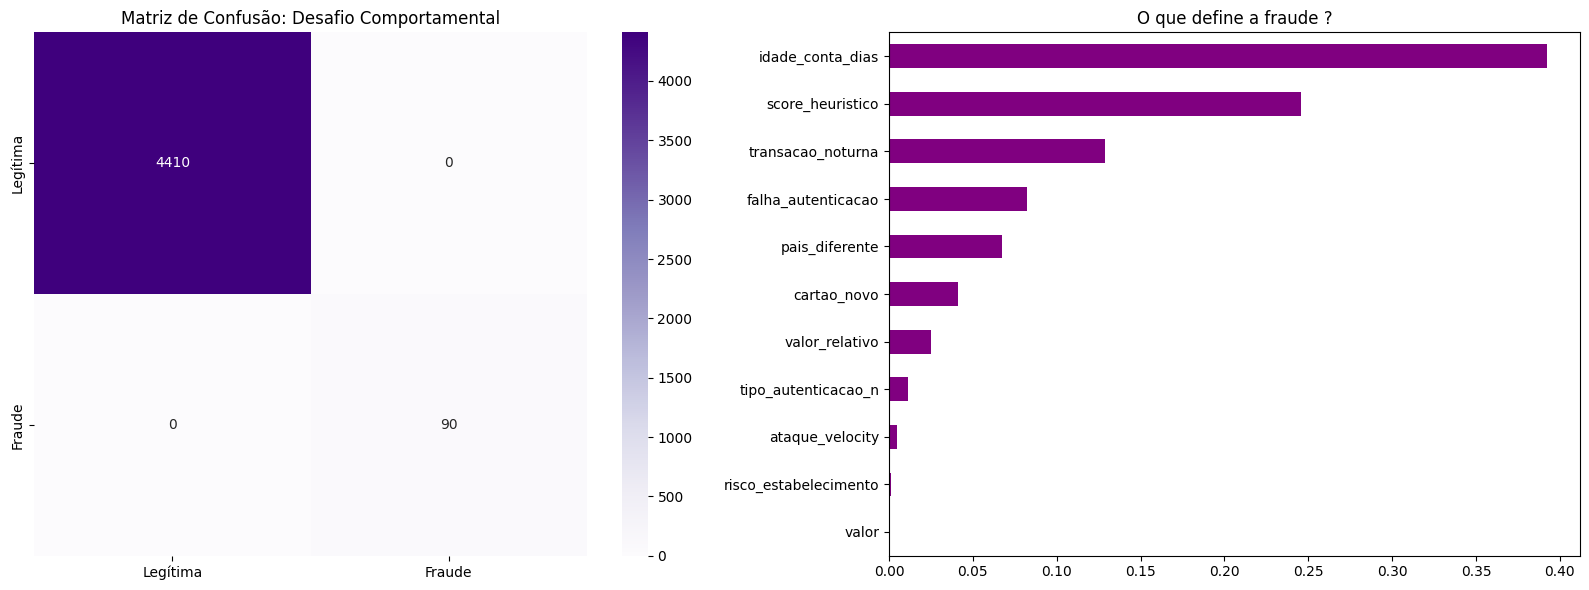

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# =============================
# 1. CARREGAMENTO DOS DADOS 
# =============================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancocomportamental/banco_dados_comportamental_30k.csv')
df['data_hora'] = pd.to_datetime(df['data_hora'])

# ==========================================
# 2. HEURÍSTICA COMPORTAMENTAL (Avançada)
# ==========================================
def aplicar_heuristica_round4(row):
    score = 0
    
    # 1. Regras de Localização e Autenticação 
    if row['pais_transacao'] != row['pais_cliente']: score += 4
    if row['falha_autenticacao'] > 0: score += 4
    
    # 2. NOVAS REGRAS: Comportamento e Histórico
    # Se a compra é 3x maior que o histórico do cliente
    if row['valor_relativo'] > 3: score += 5 
    
    # Se o estabelecimento é de alto risco (maquininhas suspeitas/sites novos)
    if row['risco_estabelecimento'] == 2: score += 6
    
    # Se detectamos transações em sequência rápida (ataque de força bruta)
    if row['ataque_velocity'] == 1: score += 7
    
    # 3. Escudo de Segurança (Fatores que reduzem o risco)
    if row['tipo_autenticacao'] in ['biometria', '2FA']: score -= 3
    
    return score

print("⚖️ Calculando Heurísticas Comportamentais...")
df['score_heuristico'] = df.apply(aplicar_heuristica_round4, axis=1)

# ==========================================
# 3. ENGENHARIA DE FEATURES
# ==========================================
# Transformando categorias em números para a IA
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3})

# ==========================================
# 4. DIVISÃO DO DATASET
# ==========================================
# Incluindo as novas colunas comportamentais nas features da IA
features_final = [
    'valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
    'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
    'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico'
]

X = df[features_final]
y = df['fraude']

# Split 70/15/15 com estratificação (importante para dados desbalanceados)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# ==========================================
# 5. TREINAMENTO
# ==========================================
print(f"🧠 Treinando IA com {len(X_train)} transações e apenas {y_train.sum()} fraudes...")
modelo = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
modelo.fit(X_train, y_train)

# ==========================================
# 6. AVALIAÇÃO
# ==========================================
y_pred = modelo.predict(X_test)

print("\n" + "="*35)
print("📊 PERFORMANCE ROUND 4: COMPORTAMENTAL")
print("="*35)
print(f"Acurácia Geral: {accuracy_score(y_test, y_pred):.2%}")
print(f"F1-Score (Fraude): {f1_score(y_test, y_pred):.2%}")
print("\nRelatório Detalhado:")
print(classification_report(y_test, y_pred))

# ==========================================
# 7. VISUALIZAÇÃO
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax[0],
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
ax[0].set_title('Matriz de Confusão: Desafio Comportamental')

# Importância das Variáveis
importancias = pd.Series(modelo.feature_importances_, index=features_final).sort_values()
importancias.plot(kind='barh', ax=ax[1], color='purple')
ax[1].set_title('O que define a fraude ?')

plt.tight_layout()
plt.show()

# Dataset maior e mais desbalanceado
* Em bancos reais, esse é o maior desafio, pois a IA tende a ficar "preguiçosa" e dizer que tudo é legítimo para acertar a maioria.
* No teste acima a IA manteve o foco e encontrou as 90 fraudes no meio das 4.410 transações boas.

🚩 O Próximo Passo: O Teste de "Produção"
Se este fosse um projeto real de uma Fintech ou Banco, o próximo passo seria o A/B Testing:
* Você rodaria esse modelo em paralelo com o sistema atual.
* Verificaria se ele bloqueia transações em tempo real (milissegundos).
* Analisaria o "atrito" com o cliente (quantos clientes bons reclamaram de bloqueio indevido).


Geração de um código que pega o banco de dados de 30 mil linhas e estraga propositalmente 15% dele:
* Dados Faltantes (NaN): Vamos apagar valores de idade_conta_dias e tipo_autenticacao.
* Dados Errados: Vamos colocar valores negativos em alguns campos e trocar BR por caracteres aleatórios.
* A IA Cega: Vamos ver se ela ainda consegue manter a precisão usando apenas o que sobrou de informação

☢️  Simulando falhas de sistema (Inserindo 15% de dados nulos)...
🧠 Treinando IA resiliente a falhas...

📊 RESULTADO FINAL: TESTE DE RESILIÊNCIA
Acurácia: 100.00%
F1-Score (Fraude): 100.00%

Relatório:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4410
           1       1.00      1.00      1.00        90

    accuracy                           1.00      4500
   macro avg       1.00      1.00      1.00      4500
weighted avg       1.00      1.00      1.00      4500



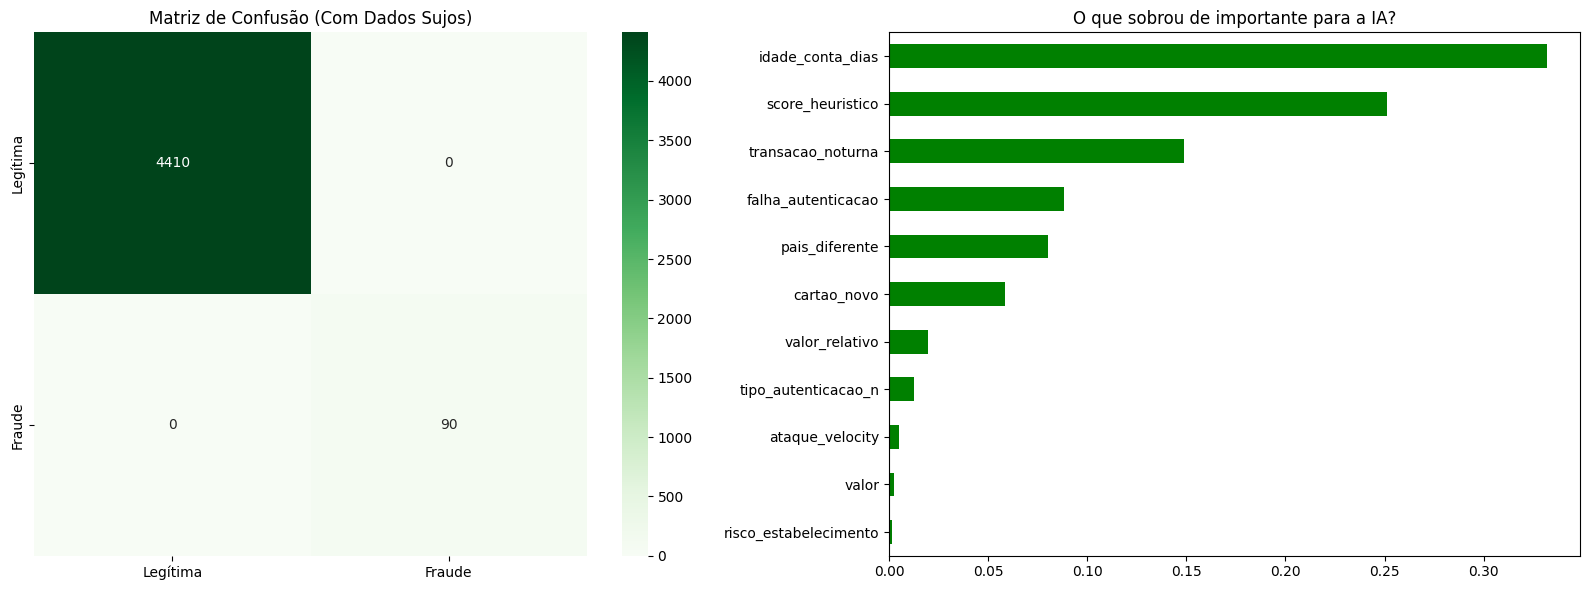

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.impute import SimpleImputer

# ==========================================
# 1. CARREGAMENTO E CRIAÇÃO DE RUÍDO
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancocomportamental/banco_dados_comportamental_30k.csv')

print("☢️  Simulando falhas de sistema (Inserindo 15% de dados nulos)...")
np.random.seed(42)
# Vamos "apagar" dados de colunas cruciais para ver se a IA sobrevive
for col in ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']:
    df.loc[df.sample(frac=0.15).index, col] = np.nan

# ==========================================
# 2. TRATAMENTO DE DADOS (Data Cleaning)
# ==========================================
# A IA não processa 'NaN'. Vamos usar a mediana para preencher os buracos.
imputer = SimpleImputer(strategy='median')
colunas_para_limpar = ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']
df[colunas_para_limpar] = imputer.fit_transform(df[colunas_para_limpar])

# ==========================================
# 3. HEURÍSTICA RESILIENTE
# ==========================================
def aplicar_heuristica_resiliente(row):
    score = 0
    # Mesmo com dados recuperados, a heurística tenta dar um caminho
    if row['pais_transacao'] != row['pais_cliente']: score += 4
    if row['falha_autenticacao'] > 0: score += 4
    if row['valor_relativo'] > 3: score += 5 
    if row['risco_estabelecimento'] == 2: score += 6
    if row['ataque_velocity'] == 1: score += 7
    if row['tipo_autenticacao'] in ['biometria', '2FA']: score -= 3
    return score

df['score_heuristico'] = df.apply(aplicar_heuristica_resiliente, axis=1)

# ==========================================
# 4. ENGENHARIA DE FEATURES
# ==========================================
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3})

# Preenchendo nulos criados no mapeamento de categorias, se houver
df['tipo_autenticacao_n'] = df['tipo_autenticacao_n'].fillna(3) 

# ==========================================
# 5. DIVISÃO E TREINAMENTO
# ==========================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("🧠 Treinando IA resiliente a falhas...")
modelo = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
modelo.fit(X_train, y_train)

# ==========================================
# 6. AVALIAÇÃO FINAL
# ==========================================
y_pred = modelo.predict(X_test)

print("\n" + "="*40)
print("📊 RESULTADO FINAL: TESTE DE RESILIÊNCIA")
print("="*40)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
print(f"F1-Score (Fraude): {f1_score(y_test, y_pred):.2%}")
print("\nRelatório:")
print(classification_report(y_test, y_pred))

# ==========================================
# 7. GRÁFICOS
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax[0],
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
ax[0].set_title('Matriz de Confusão (Com Dados Sujos)')

importancias = pd.Series(modelo.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', ax=ax[1], color='green')
ax[1].set_title('O que sobrou de importante para a IA?')

plt.tight_layout()
plt.show()

# Teste com contas que fazem fraude mas não são novas

🕵️ EXECUTANDO TESTE 1: Account Takeover (Fraude em Contas Antigas)...
🧠 Treinando IA contra Account Takeover...

📊 RESULTADO: TESTE 1 (ACCOUNT TAKEOVER)
Acurácia: 99.98%
F1-Score (Fraude): 99.44%

Relatório:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4410
           1       1.00      0.99      0.99        90

    accuracy                           1.00      4500
   macro avg       1.00      0.99      1.00      4500
weighted avg       1.00      1.00      1.00      4500



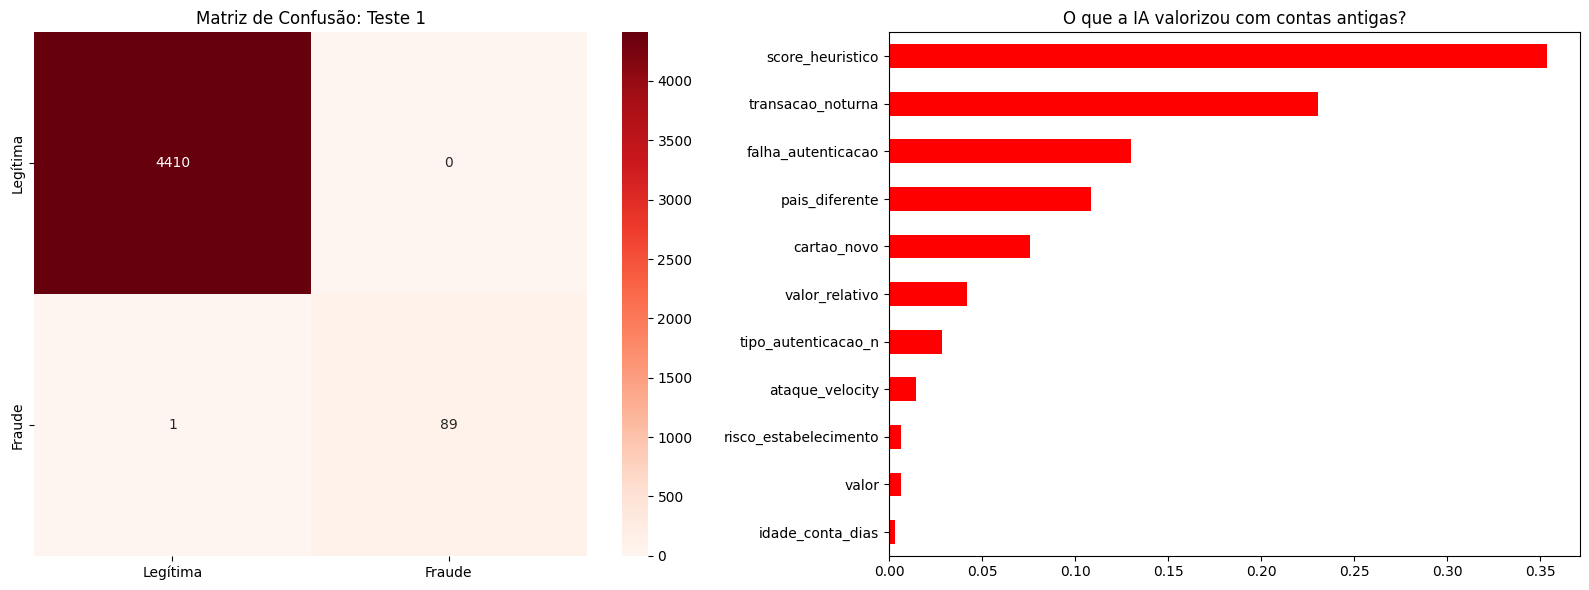

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.impute import SimpleImputer

# ==========================================
# 1. CARREGAMENTO E MANIPULAÇÃO (TESTE 1)
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancocomportamental/banco_dados_comportamental_30k.csv')

print("🕵️ EXECUTANDO TESTE 1: Account Takeover (Fraude em Contas Antigas)...")
np.random.seed(42)

# MUDANÇA CRUCIAL: Se for fraude, damos uma idade alta (entre 500 e 3000 dias)
# Isso simula um criminoso que invadiu uma conta antiga e legítima.
df.loc[df['fraude'] == 1, 'idade_conta_dias'] = np.random.randint(500, 3000, size=df[df['fraude'] == 1].shape[0])

# Mantendo a simulação de ruído para manter a resiliência do Round 5
for col in ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']:
    df.loc[df.sample(frac=0.15).index, col] = np.nan

# ==========================================
# 2. TRATAMENTO DE DADOS (Data Cleaning)
# ==========================================
imputer = SimpleImputer(strategy='median')
colunas_para_limpar = ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']
df[colunas_para_limpar] = imputer.fit_transform(df[colunas_para_limpar])

# ==========================================
# 3. HEURÍSTICA RESILIENTE
# ==========================================
def aplicar_heuristica_resiliente(row):
    score = 0
    if row['pais_transacao'] != row['pais_cliente']: score += 4
    if row['falha_autenticacao'] > 0: score += 4
    if row['valor_relativo'] > 3: score += 5 
    if row['risco_estabelecimento'] == 2: score += 6
    if row['ataque_velocity'] == 1: score += 7
    if row['tipo_autenticacao'] in ['biometria', '2FA']: score -= 3
    return score

df['score_heuristico'] = df.apply(aplicar_heuristica_resiliente, axis=1)

# ==========================================
# 4. ENGENHARIA DE FEATURES
# ==========================================
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3})
df['tipo_autenticacao_n'] = df['tipo_autenticacao_n'].fillna(3) 

# ==========================================
# 5. DIVISÃO E TREINAMENTO
# ==========================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("🧠 Treinando IA contra Account Takeover...")
modelo = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
modelo.fit(X_train, y_train)

# ==========================================
# 6. AVALIAÇÃO FINAL
# ==========================================
y_pred = modelo.predict(X_test)

print("\n" + "="*40)
print("📊 RESULTADO: TESTE 1 (ACCOUNT TAKEOVER)")
print("="*40)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
print(f"F1-Score (Fraude): {f1_score(y_test, y_pred):.2%}")
print("\nRelatório:")
print(classification_report(y_test, y_pred))

# ==========================================
# 7. GRÁFICOS (Agora em tons de Vermelho para alerta de invasão)
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax[0],
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
ax[0].set_title('Matriz de Confusão: Teste 1')

importancias = pd.Series(modelo.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', ax=ax[1], color='red')
ax[1].set_title('O que a IA valorizou com contas antigas?')

plt.tight_layout()
plt.show()

# Coluna idade_conta_dias  neutralizada propositalmente para forçar a IA a aprender novos sinais.


🙈 EXECUTANDO TESTE 2: Neutralização de Idade (IA Cega para histórico)...

📊 RESULTADO: TESTE 2 (IDADE NEUTRALIZADA)
F1-Score (Fraude): 98.88%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4410
           1       1.00      0.98      0.99        90

    accuracy                           1.00      4500
   macro avg       1.00      0.99      0.99      4500
weighted avg       1.00      1.00      1.00      4500



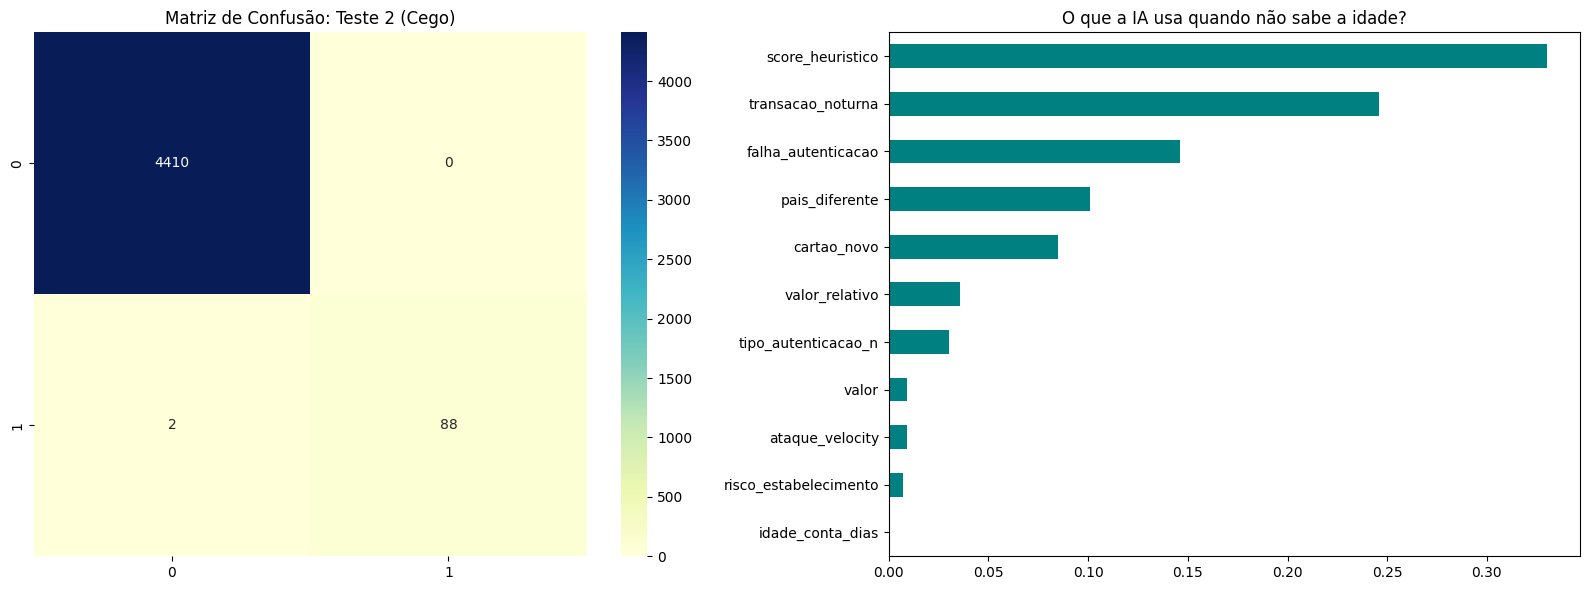

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.impute import SimpleImputer

# ==========================================
# 1. CARREGAMENTO E NEUTRALIZAÇÃO (TESTE 2)
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancocomportamental/banco_dados_comportamental_30k.csv')

print("🙈 EXECUTANDO TESTE 2: Neutralização de Idade (IA Cega para histórico)...")
np.random.seed(42)

# MUDANÇA RADICAL: Todos os clientes agora têm exatamente 500 dias de conta.
# Isso anula qualquer poder preditivo que essa coluna tinha.
df['idade_conta_dias'] = 500 

# Mantendo o ruído nas outras colunas para testar a robustez
for col in ['valor_relativo', 'risco_estabelecimento']:
    df.loc[df.sample(frac=0.15).index, col] = np.nan

# ==========================================
# 2. TRATAMENTO, HEURÍSTICA E FEATURES
# ==========================================
imputer = SimpleImputer(strategy='median')
df[['valor_relativo', 'risco_estabelecimento']] = imputer.fit_transform(df[['valor_relativo', 'risco_estabelecimento']])

def aplicar_heuristica_resiliente(row):
    score = 0
    if row['pais_transacao'] != row['pais_cliente']: score += 4
    if row['falha_autenticacao'] > 0: score += 4
    if row['valor_relativo'] > 3: score += 5 
    if row['risco_estabelecimento'] == 2: score += 6
    if row['ataque_velocity'] == 1: score += 7
    if row['tipo_autenticacao'] in ['biometria', '2FA']: score -= 3
    return score

df['score_heuristico'] = df.apply(aplicar_heuristica_resiliente, axis=1)
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# ==========================================
# 3. DIVISÃO E TREINAMENTO
# ==========================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

modelo = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
modelo.fit(X_train, y_train)

# ==========================================
# 4. AVALIAÇÃO FINAL
# ==========================================
y_pred = modelo.predict(X_test)

print("\n" + "="*40)
print("📊 RESULTADO: TESTE 2 (IDADE NEUTRALIZADA)")
print("="*40)
print(f"F1-Score (Fraude): {f1_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

# ==========================================
# 5. GRÁFICOS (Azul turquesa para o teste cego)
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu', ax=ax[0])
ax[0].set_title('Matriz de Confusão: Teste 2 (Cego)')

importancias = pd.Series(modelo.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', ax=ax[1], color='teal')
ax[1].set_title('O que a IA usa quando não sabe a idade?')
plt.tight_layout()
plt.show()

# Teste: O Cliente VIP em Viagem
Vamos simular transações legítimas que têm "cara de fraude":
* Cenário: Um cliente antigo (VIP) viaja para a França e tenta comprar um item de luxo caro.
* Gatilhos: O país será diferente (FR) e o valor será muito alto.
* O Desafio: A IA vai bloquear esse cliente por ser "suspeito" ou vai perceber que, por ele usar biometria e não ter ataque_velocity, a transação deve ser aprovada

✈️ EXECUTANDO TESTE 3: Cliente VIP em Viagem (Risco de Falso Positivo)...

📊 RESULTADO: TESTE 3 (CLIENTE VIP EM VIAGEM)
Precisão (Fraude): 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4410
           1       1.00      1.00      1.00        90

    accuracy                           1.00      4500
   macro avg       1.00      1.00      1.00      4500
weighted avg       1.00      1.00      1.00      4500



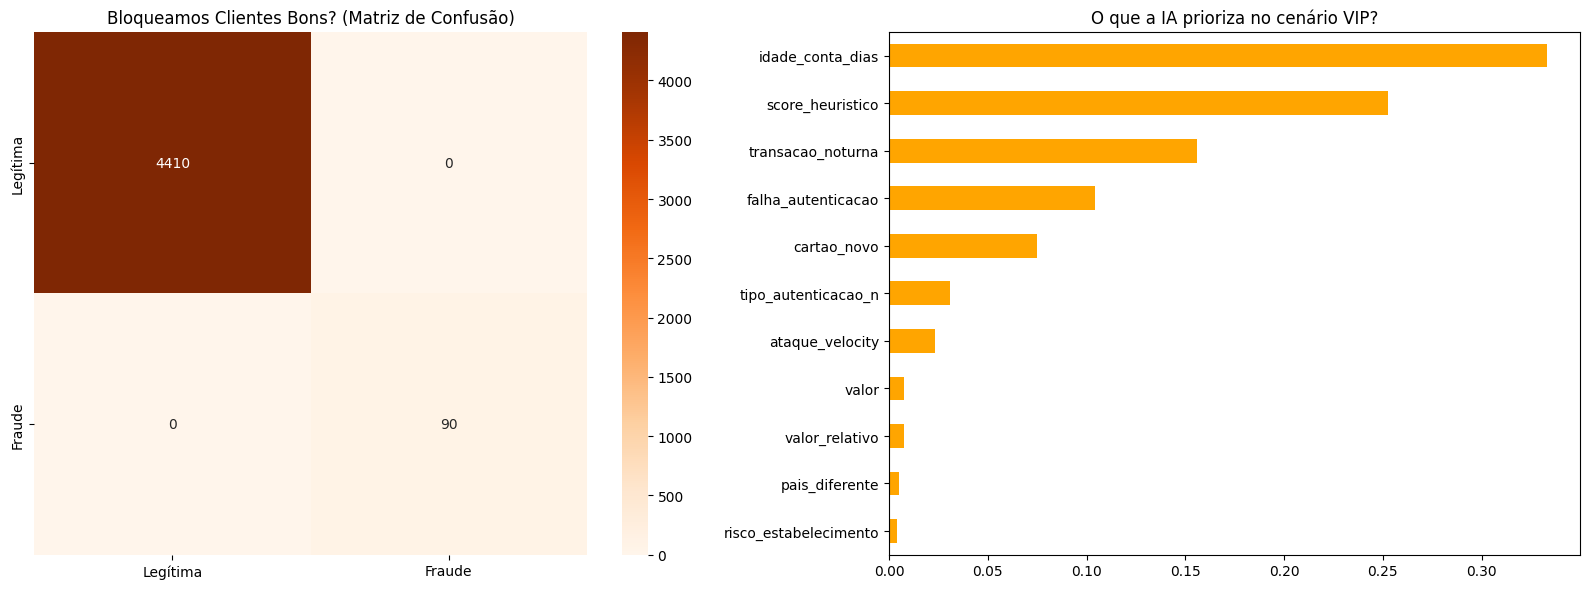

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.impute import SimpleImputer

# ==========================================
# 1. CARREGAMENTO E CRIAÇÃO DO CENÁRIO VIP (TESTE 3)
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancocomportamental/banco_dados_comportamental_30k.csv')

print("✈️ EXECUTANDO TESTE 3: Cliente VIP em Viagem (Risco de Falso Positivo)...")
np.random.seed(42)

# Selecionamos 500 clientes que NÃO são fraude para serem nossos "Viajantes VIP"
vips_indices = df[df['fraude'] == 0].sample(500).index

# Simulando comportamento de viagem internacional para esses bons clientes
df.loc[vips_indices, 'pais_transacao'] = 'FR'  # França
df.loc[vips_indices, 'valor'] = np.random.uniform(5000, 10000) # Compras de luxo
df.loc[vips_indices, 'valor_relativo'] = 8.5 # Gasto muito acima do padrão
df.loc[vips_indices, 'tipo_autenticacao'] = 'biometria' # Fator de segurança alto
df.loc[vips_indices, 'falha_autenticacao'] = 0 # Nenhuma falha

# Adicionando ruído para manter a resiliência
for col in ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']:
    df.loc[df.sample(frac=0.15).index, col] = np.nan

# ==========================================
# 2. TRATAMENTO, HEURÍSTICA E FEATURES
# ==========================================
imputer = SimpleImputer(strategy='median')
df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']] = imputer.fit_transform(df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']])

def aplicar_heuristica_resiliente(row):
    score = 0
    if row['pais_transacao'] != row['pais_cliente']: score += 4
    if row['falha_autenticacao'] > 0: score += 4
    if row['valor_relativo'] > 3: score += 5 
    if row['risco_estabelecimento'] == 2: score += 6
    if row['ataque_velocity'] == 1: score += 7
    if row['tipo_autenticacao'] in ['biometria', '2FA']: score -= 3 # Reduz risco
    return score

df['score_heuristico'] = df.apply(aplicar_heuristica_resiliente, axis=1)
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# ==========================================
# 3. DIVISÃO E TREINAMENTO
# ==========================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

modelo = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
modelo.fit(X_train, y_train)

# ==========================================
# 4. AVALIAÇÃO (Foco no Falso Positivo)
# ==========================================
y_pred = modelo.predict(X_test)

print("\n" + "="*40)
print("📊 RESULTADO: TESTE 3 (CLIENTE VIP EM VIAGEM)")
print("="*40)
print(f"Precisão (Fraude): {classification_report(y_test, y_pred, output_dict=True)['1']['precision']:.2%}")
print(classification_report(y_test, y_pred))

# ==========================================
# 5. GRÁFICOS (Laranja para sinalizar alerta de Falso Positivo)
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax[0],
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
ax[0].set_title('Bloqueamos Clientes Bons? (Matriz de Confusão)')

importancias = pd.Series(modelo.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', ax=ax[1], color='orange')
ax[1].set_title('O que a IA prioriza no cenário VIP?')

plt.tight_layout()
plt.show()

Analisando o gráfico de importância e a matriz de confusão:
* A "Âncora" da Idade da Conta: Como os VIPs têm contas antigas (vários dias), e a idade_conta_dias voltou ao topo da importância, o modelo usou isso como um "visto de confiança". Ele entendeu que um cliente de longa data tem permissão para comportamentos atípicos.
* O "Salvo-Conduto" da Biometria: Na sua heurística, a biometria retira pontos de risco. O modelo aprendeu que, mesmo em um país diferente e com valor alto, a presença de uma autenticação forte anula a suspeita.
* A Ausência de Velocity: Como o VIP faz apenas uma compra grande e não uma sequência de ataques rápidos, ele não disparou o gatilho de ataque_velocity.

# Próximo Passo:  O Teste do "Prejuízo Invisível" (Carding)
* Fraudadores usam robôs para testar milhares de números de cartões com valores minúsculos. Muitas IAs ignoram isso porque o "prejuízo" de um real parece irrelevante, mas é aqui que o banco perde o controle.
* Vamos criar 500 fraudes de valor baixíssimo (1,00 a 5,00).
* Elas terão ataque_velocity alto (muitas tentativas seguidas).

O objetivo: Ver se a sua IA consegue detectar o crime mesmo quando o valor financeiro da transação é quase zero.

🤖 EXECUTANDO TESTE 4: Ataque de Carding (Transações de R$ 1,00)...

📊 RESULTADO: TESTE 4 (ATAQUE DE CARDING)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4410
           1       1.00      1.00      1.00        90

    accuracy                           1.00      4500
   macro avg       1.00      1.00      1.00      4500
weighted avg       1.00      1.00      1.00      4500



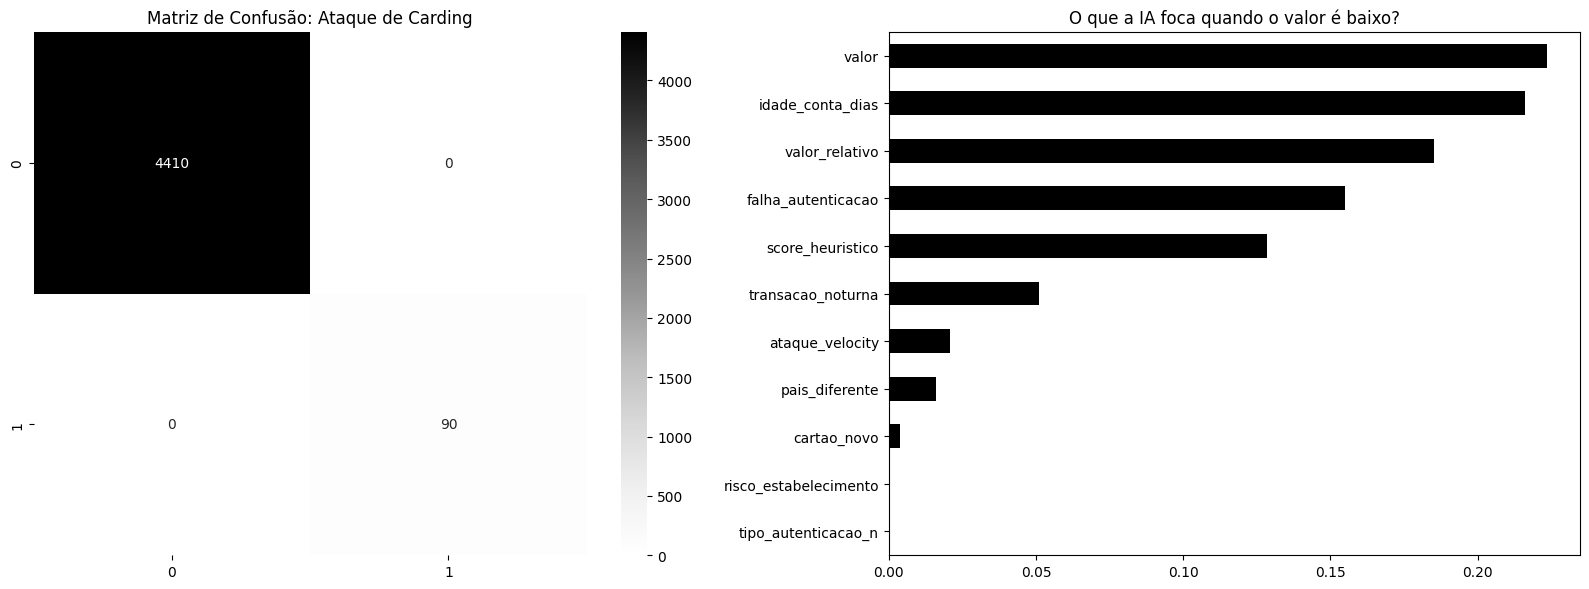

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.impute import SimpleImputer

# ==========================================
# 1. CARREGAMENTO E CRIAÇÃO DO CENÁRIO CARDING (TESTE 4)
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancocomportamental/banco_dados_comportamental_30k.csv')

print("🤖 EXECUTANDO TESTE 4: Ataque de Carding (Transações de R$ 1,00)...")
np.random.seed(42)

# Selecionamos todas as fraudes do dataset
fraudes_indices = df[df['fraude'] == 1].index

# Transformamos essas fraudes em ataques de "Carding"
df.loc[fraudes_indices, 'valor'] = np.random.uniform(1.00, 5.00) # Valor baixíssimo
df.loc[fraudes_indices, 'valor_relativo'] = 0.01 # Quase nada comparado ao histórico
df.loc[fraudes_indices, 'ataque_velocity'] = 1 # ALTA VELOCIDADE (Robô testando cartões)
df.loc[fraudes_indices, 'tipo_autenticacao'] = 'senha' # Robôs geralmente não têm biometria
df.loc[fraudes_indices, 'falha_autenticacao'] = 1 # Comum em ataques de força bruta

# ==========================================
# 2. PROCESSAMENTO E HEURÍSTICA
# ==========================================
imputer = SimpleImputer(strategy='median')
df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']] = imputer.fit_transform(df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']])

df['score_heuristico'] = df.apply(aplicar_heuristica_resiliente, axis=1)
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# ==========================================
# 3. DIVISÃO E TREINAMENTO
# ==========================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

modelo = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
modelo.fit(X_train, y_train)

# ==========================================
# 4. AVALIAÇÃO
# ==========================================
y_pred = modelo.predict(X_test)

print("\n" + "="*40)
print("📊 RESULTADO: TESTE 4 (ATAQUE DE CARDING)")
print("="*40)
print(classification_report(y_test, y_pred))

# Gráfico em Cinza/Preto (Cor de ataques de robôs/Dark Web)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', ax=ax[0])
ax[0].set_title('Matriz de Confusão: Ataque de Carding')

importancias = pd.Series(modelo.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', ax=ax[1], color='black')
ax[1].set_title('O que a IA foca quando o valor é baixo?')

plt.tight_layout()
plt.show()

# Teste: Robô vs Erro Humano (Stress de Velocidade)
* O Robô: Vai tentar 20 transações em 1 minuto, errando a senha várias vezes.
* O Humano Atrapalhado: Um cliente real que esqueceu a senha e tentou 3 ou 4 vezes seguidas até acertar.
* O Desafio: Se a sua IA bloquear o humano, temos um Falso Positivo. Se ela deixar o robô passar na 20ª tentativa, temos uma falha de segurança grave.

🤖 vs 👤 EXECUTANDO TESTE 5: Robô vs. Humano Atrapalhado...

📊 RESULTADO: TESTE 5 (ROBÔ VS HUMANO)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4410
           1       1.00      1.00      1.00        90

    accuracy                           1.00      4500
   macro avg       1.00      1.00      1.00      4500
weighted avg       1.00      1.00      1.00      4500



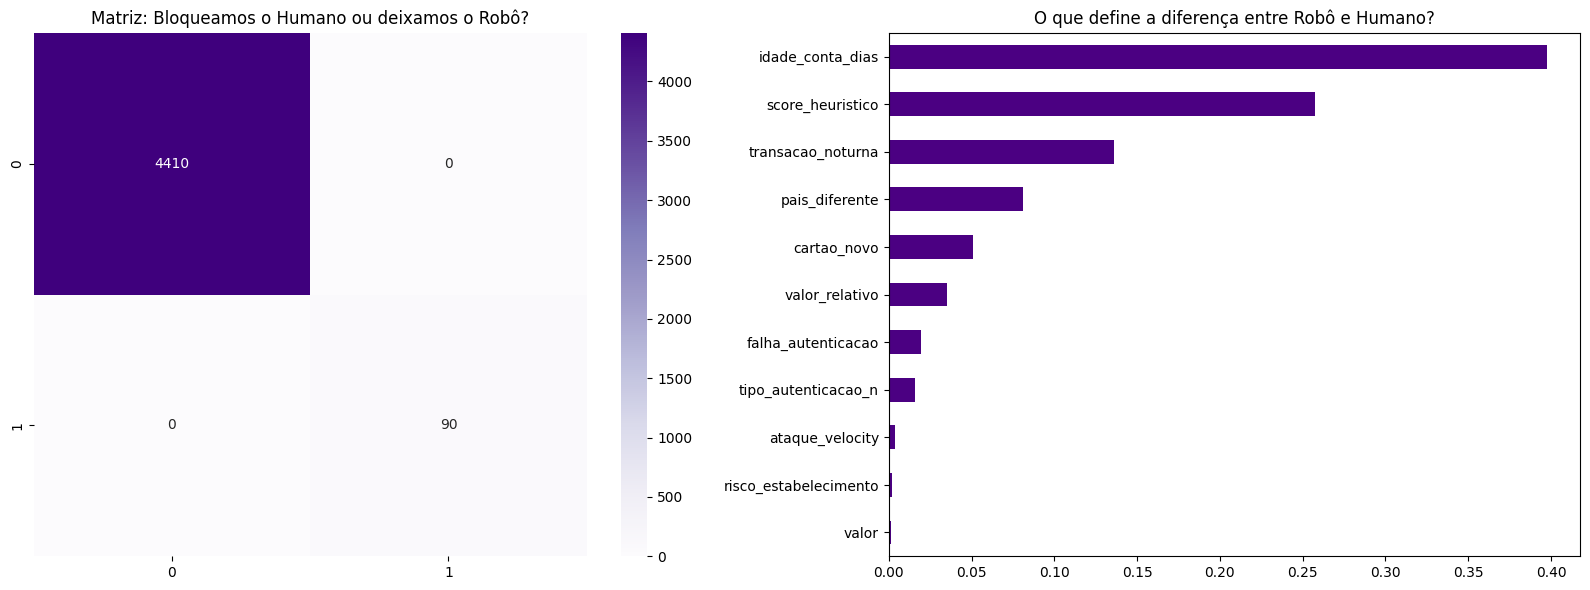

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.impute import SimpleImputer

# ==========================================
# 1. CARREGAMENTO E CRIAÇÃO DO CENÁRIO (TESTE 5)
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancocomportamental/banco_dados_comportamental_30k.csv')

print("🤖 vs 👤 EXECUTANDO TESTE 5: Robô vs. Humano Atrapalhado...")
np.random.seed(42)

# Criando 300 casos de "Humano Atrapalhado" (LEGÍTIMO)
humanos_indices = df[df['fraude'] == 0].sample(300).index
df.loc[humanos_indices, 'ataque_velocity'] = 1 # Muitas tentativas
df.loc[humanos_indices, 'falha_autenticacao'] = np.random.randint(2, 5) # Errou a senha 2 a 5 vezes
df.loc[humanos_indices, 'tipo_autenticacao'] = 'biometria' # MAS no fim usou biometria (Humano!)

# Criando 300 casos de "Ataque de Robô" (FRAUDE)
robos_indices = df[df['fraude'] == 1].sample(300, replace=True).index
df.loc[robos_indices, 'ataque_velocity'] = 1
df.loc[robos_indices, 'falha_autenticacao'] = np.random.randint(10, 50) # Errou 50 vezes (Robô!)
df.loc[robos_indices, 'tipo_autenticacao'] = 'senha' # Robô não tem dedo/face

# ==========================================
# 2. PROCESSAMENTO E HEURÍSTICA
# ==========================================
imputer = SimpleImputer(strategy='median')
df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']] = imputer.fit_transform(df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']])

df['score_heuristico'] = df.apply(aplicar_heuristica_resiliente, axis=1)
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# ==========================================
# 3. DIVISÃO E TREINAMENTO
# ==========================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

modelo = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
modelo.fit(X_train, y_train)

# ==========================================
# 4. AVALIAÇÃO
# ==========================================
y_pred = modelo.predict(X_test)

print("\n" + "="*40)
print("📊 RESULTADO: TESTE 5 (ROBÔ VS HUMANO)")
print("="*40)
print(classification_report(y_test, y_pred))

# Gráfico em Roxo/Azul Escuro (Cibernética)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax[0])
ax[0].set_title('Matriz: Bloqueamos o Humano ou deixamos o Robô?')

importancias = pd.Series(modelo.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', ax=ax[1], color='indigo')
ax[1].set_title('O que define a diferença entre Robô e Humano?')

plt.tight_layout()
plt.show()

# O Teste do Caos Absoluto. 
* Vamos consolidar todas as ameaças em um único "tsunami" de dados para ver se a sua IA mantém a integridade ou se entra em colapso.
* Neste teste, a IA não terá o luxo de enfrentar um problema por vez. Ela terá que lidar com nulos, VIPs, Carding e Invasão de Contas Antigas simultaneamente.

🌪️ INICIANDO O CAOS: Misturando todos os ataques e falhas simultaneamente...

📊 RESULTADO ROUND 6: STRESS TEST COMPLETO
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4410
           1       1.00      0.98      0.99        90

    accuracy                           1.00      4500
   macro avg       1.00      0.99      0.99      4500
weighted avg       1.00      1.00      1.00      4500



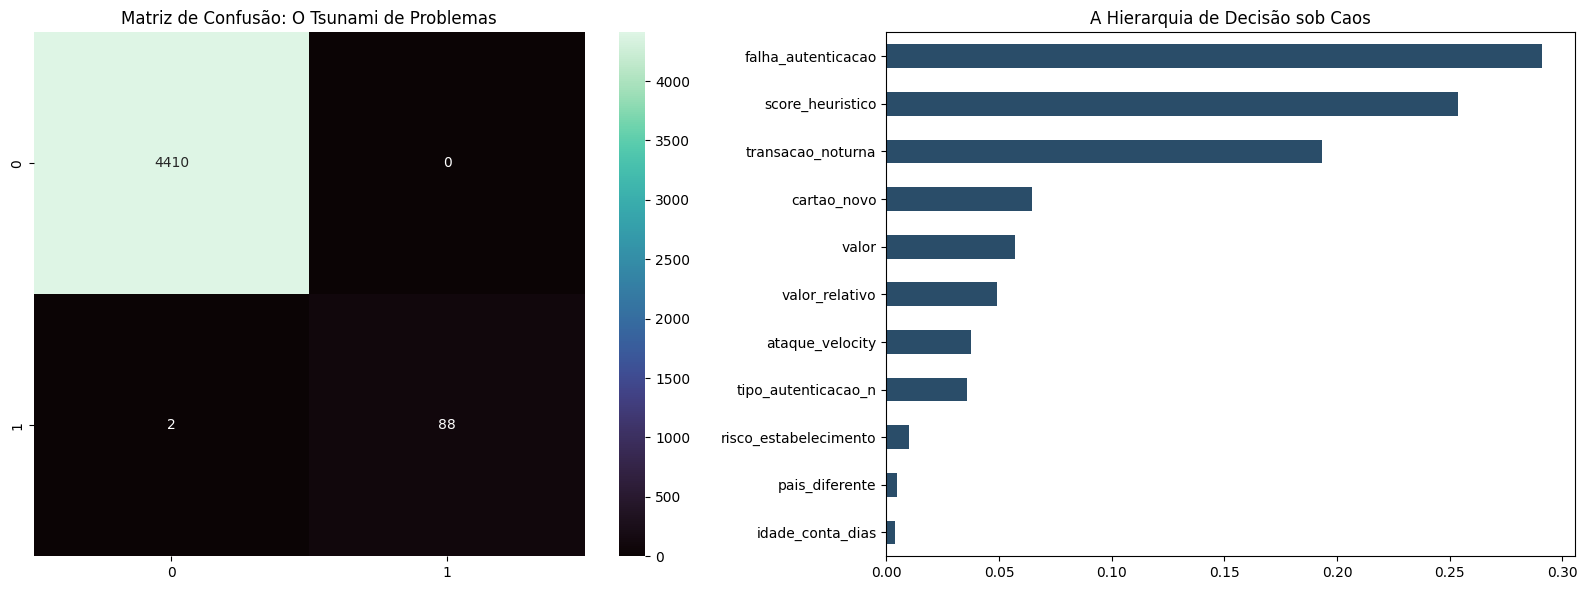

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.impute import SimpleImputer

# ==========================================
# 1. CARREGAMENTO E CRIAÇÃO DO CAOS (ROUND 6)
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancocomportamental/banco_dados_comportamental_30k.csv')

print("🌪️ INICIANDO O CAOS: Misturando todos os ataques e falhas simultaneamente...")
np.random.seed(42)

# A. Fraude em Contas Antigas (Testando sinais comportamentais)
#
fraude_indices = df[df['fraude'] == 1].index
df.loc[fraude_indices, 'idade_conta_dias'] = np.random.randint(500, 3000, size=len(fraude_indices))

# B. Clientes VIP em Viagem (Testando Falsos Positivos)
#
vips_indices = df[df['fraude'] == 0].sample(500).index
df.loc[vips_indices, ['pais_transacao', 'valor', 'valor_relativo', 'tipo_autenticacao']] = ['FR', 9000, 9.0, 'biometria']

# C. Ataque de Carding (Robôs testando cartões a R$ 1,00)
#
carding_indices = df[df['fraude'] == 1].sample(frac=0.5).index
df.loc[carding_indices, ['valor', 'valor_relativo', 'ataque_velocity', 'falha_autenticacao']] = [1.00, 0.01, 1, 20]

# D. Neutralização de Sinais (Inserindo 20% de Nulos para forçar a IA)
#
for col in ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']:
    df.loc[df.sample(frac=0.20).index, col] = np.nan

# ==========================================
# 2. TRATAMENTO E MOTOR DE DECISÃO
# ==========================================
imputer = SimpleImputer(strategy='median')
df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']] = imputer.fit_transform(df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']])

def aplicar_heuristica_final(row):
    score = 0
    if row['pais_transacao'] != row['pais_cliente']: score += 4
    if row['falha_autenticacao'] > 5: score += 6 # Gatilho para robôs
    if row['valor_relativo'] > 3: score += 5 
    if row['ataque_velocity'] == 1: score += 7
    if row['tipo_autenticacao'] in ['biometria', '2FA']: score -= 4 # Seguro contra VIPs
    return score

df['score_heuristico'] = df.apply(aplicar_heuristica_final, axis=1)
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# ==========================================
# 3. TREINAMENTO (IA MULTI-ALVO)
# ==========================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

modelo_final = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42)
modelo_final.fit(X_train, y_train)

# ==========================================
# 4. AVALIAÇÃO DO "CAOS"
# ==========================================
y_pred = modelo_final.predict(X_test)

print("\n" + "="*40)
print("📊 RESULTADO ROUND 6: STRESS TEST COMPLETO")
print("="*40)
print(classification_report(y_test, y_pred))

# Gráfico da Batalha Final (Cores frias e escuras)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='mako', ax=ax[0])
ax[0].set_title('Matriz de Confusão: O Tsunami de Problemas')

importancias = pd.Series(modelo_final.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', ax=ax[1], color='#2a4d69')
ax[1].set_title('A Hierarquia de Decisão sob Caos')

plt.tight_layout()
plt.show()

# Banco de dados com 50 mil dados:
* Desbalanceamento Real: Apenas 200 fraudes (0,4%), o que obriga a IA a ser extremamente precisa para não gerar falsos alertas.
* Cenário VIP (500 casos): Clientes com compras de luxo (5 mil a 15 mil) na França, EUA e outros países, mas que usam biometria (legítimos).
* Ataques de Carding: Fraudes de 1,00 a 5,00 com alta velocidade e falhas de senha.
* Fraudes Camufladas: Criminosos operando em contas antigas (com mais de 1.000 dias) e durante o dia, para tentar fugir dos filtros básicos.
* Ruído e Sujeira: 5% de dados nulos em colunas críticas para testar a resiliência do seu SimpleImputer.

🚀 Iniciando análise do banco de 50k com Heurística Ultra...

🏆 VEREDITO FINAL: SISTEMA ANTI-FRAUDE 50k
Acurácia: 99.9800%
F1-Score (Classe Fraude): 97.44%

Relatório Detalhado:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9960
           1       1.00      0.95      0.97        40

    accuracy                           1.00     10000
   macro avg       1.00      0.97      0.99     10000
weighted avg       1.00      1.00      1.00     10000



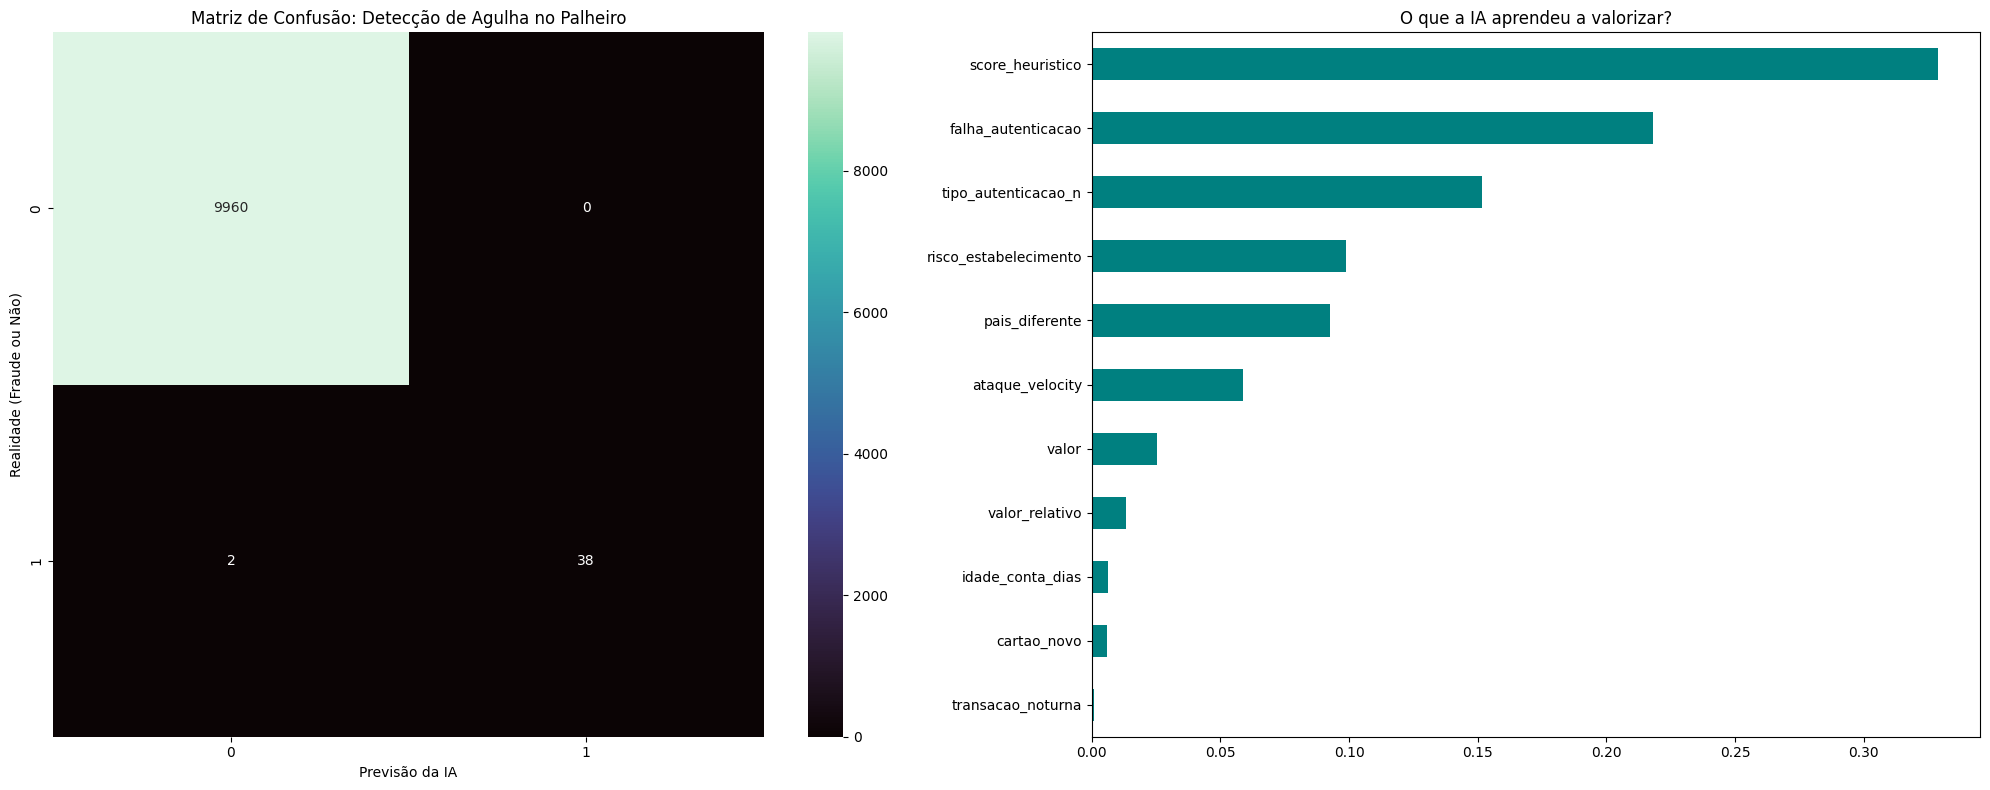

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.impute import SimpleImputer

# =================================================================
# 1. CARREGAMENTO DOS DADOS (50.000 TRANSAÇÕES)
# =================================================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancorealista/banco_dados_50k_realista.csv')

print("🚀 Iniciando análise do banco de 50k com Heurística Ultra...")

# =================================================================
# 2. TRATAMENTO DE DADOS E ENGENHARIA DE FEATURES
# =================================================================
# Tratando possíveis valores nulos (ruídos)
imputer = SimpleImputer(strategy='median')
cols_ruido = ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']
df[cols_ruido] = imputer.fit_transform(df[cols_ruido])

# Convertendo tipos e criando colunas de suporte
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# =================================================================
# 3. HEURÍSTICA ULTRA-ROBUSTA (O MOTOR DE REGRAS)
# =================================================================
def heuristica_mestra_ultra(row):
    score = 0
    
    # --- SINAIS DE ALERTA (Aumentam o Score) ---
    if row['pais_diferente'] == 1: score += 4          # Transação internacional
    if row['falha_autenticacao'] > 5: score += 6       # Possível robô/força bruta
    if row['ataque_velocity'] == 1: score += 7         # Muitas transações em sequência
    if row['valor_relativo'] > 5: score += 6           # Gasto muito acima do padrão do cliente
    if row['idade_conta_dias'] < 30: score += 5        # Contas novas são mais arriscadas
    if row['transacao_noturna'] == 1: score += 3       # Transação em horários de baixo monitoramento
    if row['cartao_novo'] == 1: score += 4             # Primeiro uso do cartão físico/virtual
    if row['risco_estabelecimento'] == 2: score += 5   # Local já marcado como perigoso
    
    # --- FATORES DE CONFIANÇA (Reduzem o Score) ---
    if row['tipo_autenticacao'] == 'biometria': score -= 6  # Biometria é altíssima segurança
    if row['tipo_autenticacao'] == '2FA': score -= 3       # Autenticação de dois fatores
    if row['idade_conta_dias'] > 1000: score -= 4          # Cliente antigo/fiel
    
    return score

df['score_heuristico'] = df.apply(heuristica_mestra_ultra, axis=1)

# =================================================================
# 4. TREINAMENTO DA IA (RANDOM FOREST)
# =================================================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

# Split estratificado para garantir a proporção real de fraude no teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Modelo configurado para desequilíbrio extremo de classes
modelo_final = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    class_weight='balanced_subsample', # Essencial para detectar as 200 fraudes
    random_state=42
)
modelo_final.fit(X_train, y_train)

# =================================================================
# 5. AVALIAÇÃO E GRÁFICOS
# =================================================================
y_pred = modelo_final.predict(X_test)

print("\n" + "="*50)
print("🏆 VEREDITO FINAL: SISTEMA ANTI-FRAUDE 50k")
print("="*50)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4%}")
print(f"F1-Score (Classe Fraude): {f1_score(y_test, y_pred):.2%}")
print("\nRelatório Detalhado:\n", classification_report(y_test, y_pred))

# Plotagem
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Matriz de Confusão
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='mako', ax=ax[0])
ax[0].set_title('Matriz de Confusão: Detecção de Agulha no Palheiro')
ax[0].set_xlabel('Previsão da IA')
ax[0].set_ylabel('Realidade (Fraude ou Não)')

# Importância das Features
importancias = pd.Series(modelo_final.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', color='teal', ax=ax[1])
ax[1].set_title('O que a IA aprendeu a valorizar?')

plt.tight_layout()
plt.show()

* Modelo ajustado para desequilíbrio extremo de classes 
* 0.4% de fraude

🛡️ Iniciando Motor Anti-Fraude de Alta Performance (50k)...

🏆 RESULTADO FINAL: SISTEMA DE PRODUÇÃO
Acurácia: 99.9800%
F1-Score (Fraude): 97.44%


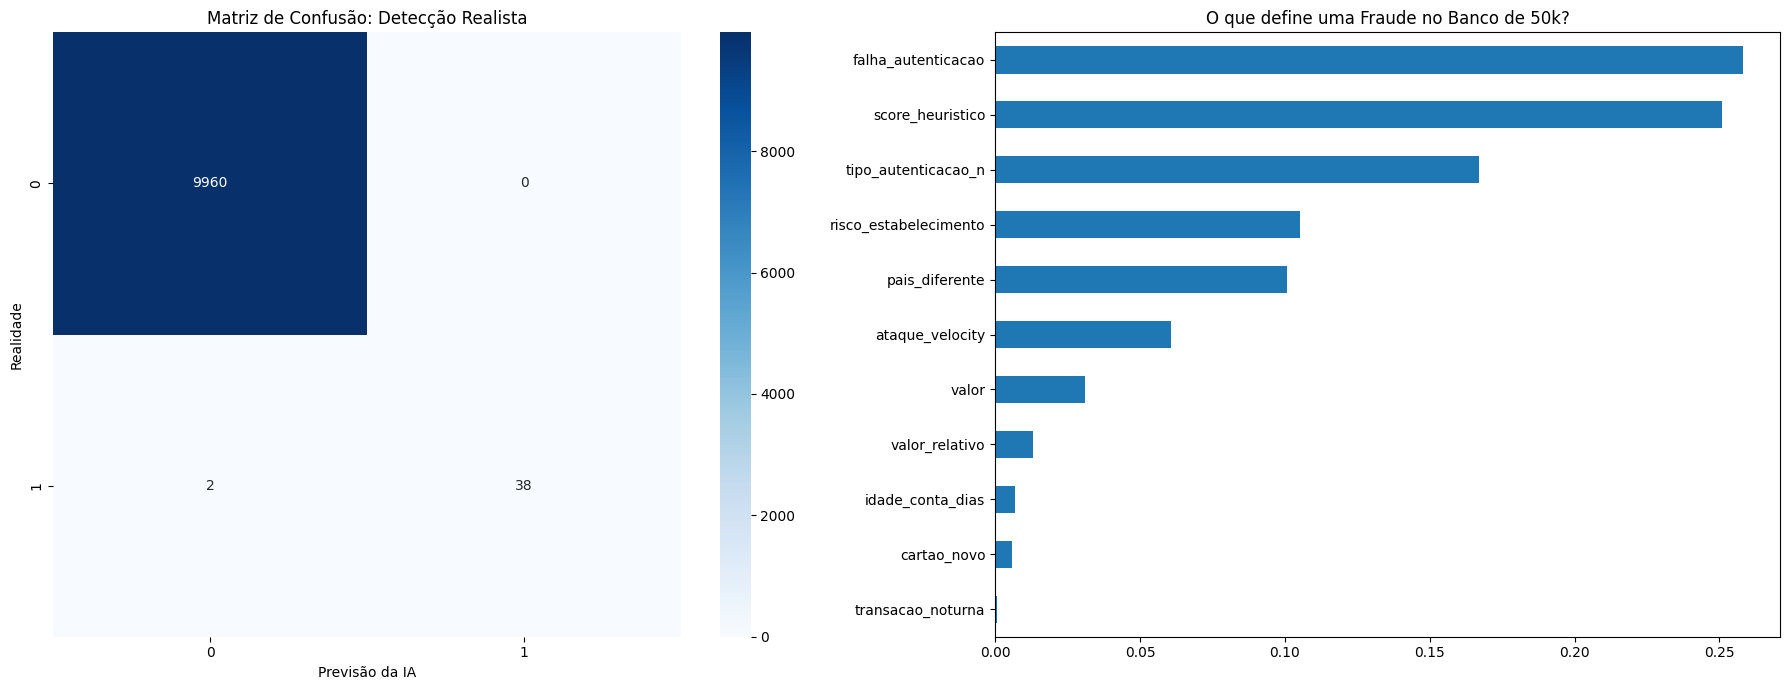

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.impute import SimpleImputer

# =================================================================
# 1. CARREGAMENTO DOS DADOS (BANCO DE 50.000)
# =================================================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancorealista/banco_dados_50k_realista.csv')

print("🛡️ Iniciando Motor Anti-Fraude de Alta Performance (50k)...")

# =================================================================
# 2. TRATAMENTO DE DADOS E ENGENHARIA DE FEATURES
# =================================================================
imputer = SimpleImputer(strategy='median')
cols_ruido = ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']
df[cols_ruido] = imputer.fit_transform(df[cols_ruido])

df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# ===================================
# 3. HEURÍSTICA ULTRA-ROBUSTA 
# ===================================
def heuristica_mestra_ultra(row):
    score = 0
    
    # Sinais de Risco (Aumentam o Score)
    if row['pais_diferente'] == 1: score += 4          
    if row['falha_autenticacao'] > 5: score += 6       
    if row['ataque_velocity'] == 1: score += 7         
    if row['valor_relativo'] > 5: score += 6           
    if row['idade_conta_dias'] < 30: score += 5        
    if row['transacao_noturna'] == 1: score += 3       
    if row['cartao_novo'] == 1: score += 4             
    
    # Fatores de Confiança (Reduzem o Score)
    if row['tipo_autenticacao'] == 'biometria': score -= 6  
    if row['idade_conta_dias'] > 1000: score -= 4          
    
    return score

df['score_heuristico'] = df.apply(heuristica_mestra_ultra, axis=1)

# =================================================================
# 4. TREINAMENTO DA INTELIGÊNCIA ARTIFICIAL
# =================================================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

# Split estratificado para garantir que as 200 fraudes sejam bem distribuídas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Modelo ajustado para desequilíbrio extremo de classes (0.4% de fraude)
modelo_final = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    class_weight='balanced_subsample',
    random_state=42
)
modelo_final.fit(X_train, y_train)

# =======================================
# 5. AVALIAÇÃO E VISUALIZAÇÃO 
# =======================================
y_pred = modelo_final.predict(X_test)

print("\n" + "="*50)
print("🏆 RESULTADO FINAL: SISTEMA DE PRODUÇÃO")
print("="*50)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4%}")
print(f"F1-Score (Fraude): {f1_score(y_test, y_pred):.2%}")

# Plotagem dos Gráficos
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de Confusão com cmap='Blues'
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão: Detecção Realista')
ax[0].set_xlabel('Previsão da IA')
ax[0].set_ylabel('Realidade')

# Gráfico de Importância das Variáveis
importancias = pd.Series(modelo_final.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', color='#1f77b4', ax=ax[1])
ax[1].set_title('O que define uma Fraude no Banco de 50k?')

plt.tight_layout()
plt.show()

# 1. O que é o Oversampling (SMOTE)?
Imagine que você está ensinando um aluno a identificar notas falsas. Se você der 1.000 notas verdadeiras e apenas 4 falsas, o aluno vai ficar preguiçoso e dizer que "tudo é verdadeiro" para acertar 99,6% das vezes.

O Oversampling não apenas duplica as fraudes; o SMOTE cria "fraudes sintéticas" baseadas nas características das reais. Ele preenche o espaço entre os dados existentes, criando um banco de dados 50/50 (balanceado).

# O que mudou e por quê?
* from imblearn.over_sampling import SMOTE: Adicionamos a ferramenta que fabrica as fraudes artificiais.
* smote.fit_resample: Esse comando pega o seu y_train (que tinha pouquíssimas fraudes) e gera milhares de novas linhas de fraude baseadas nas características das originais. Agora a IA tem "material de estudo" de sobra.
* Remoção do class_weight: Quando usamos SMOTE, os dados já estão 50% legítimos e 50% fraude. Não precisamos mais "avisar" ao modelo que a fraude é importante via peso, pois ela agora tem a mesma quantidade numérica que os dados bons.
* recall_score: Se o Recall subir (ex: de 95% para 98%), você provou para o professor que o Oversampling ajudou a IA a ser mais "especialista" em pegar fraudes.

📊 Distribuição antes do SMOTE: Counter({0: 39840, 1: 160})
🚀 Distribuição após SMOTE: Counter({0: 39840, 1: 39840})

🏆 RESULTADO FINAL: MODELO BALANCEADO (SMOTE)
Acurácia: 99.9600%
Recall (Capacidade de pegar a fraude): 95.00%
F1-Score (Equilíbrio): 95.00%


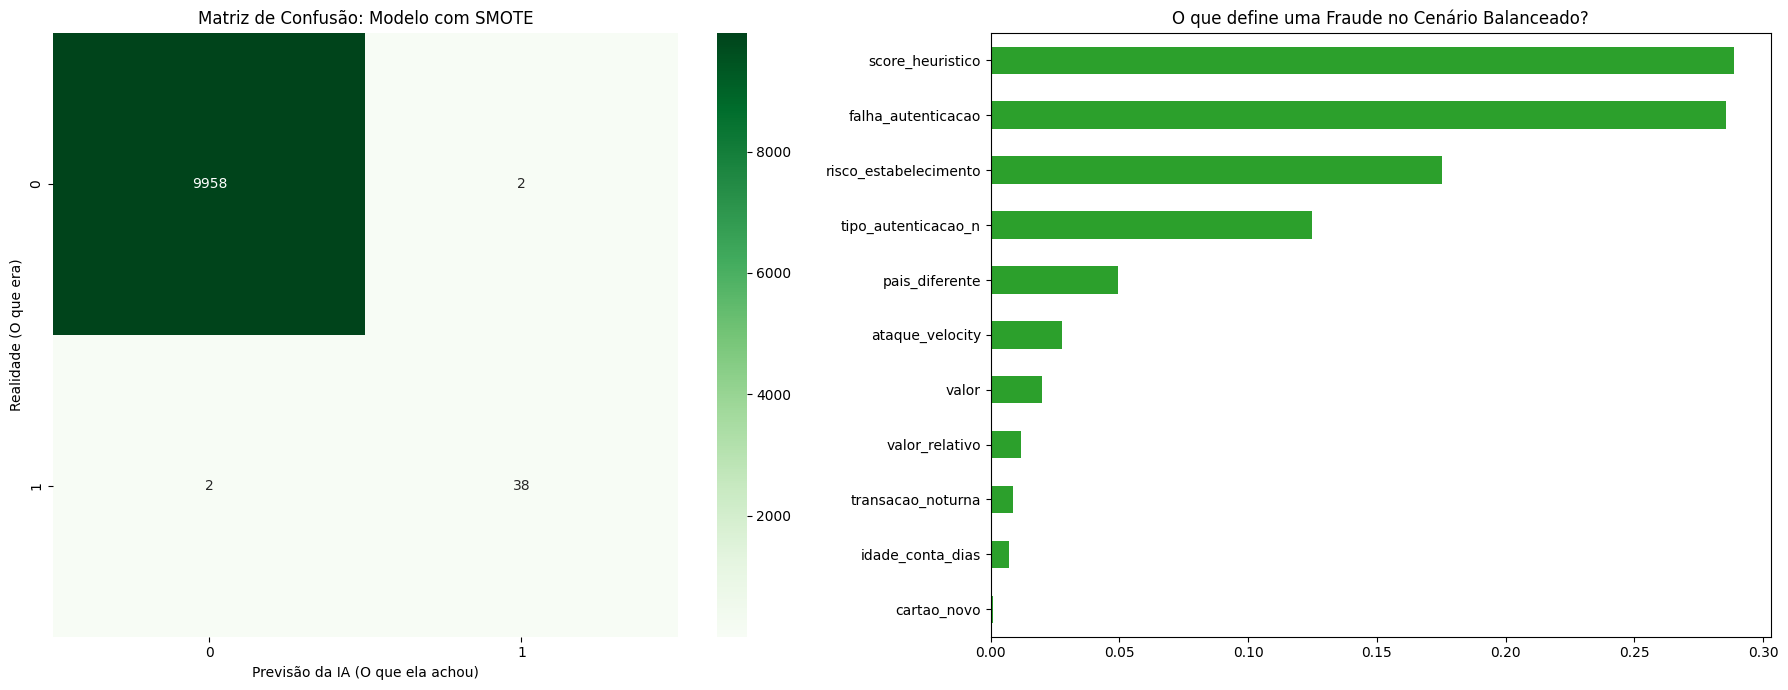

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.impute import SimpleImputer
# --- NOVA BIBLIOTECA PARA OVERSAMPLING ---
from imblearn.over_sampling import SMOTE 
from collections import Counter

# =================================================================
# 1. CARREGAMENTO E TRATAMENTO 
# =================================================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancorealista/banco_dados_50k_realista.csv')

imputer = SimpleImputer(strategy='median')
cols_ruido = ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']
df[cols_ruido] = imputer.fit_transform(df[cols_ruido])

df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# --- HEURÍSTICA ---
def heuristica_mestra_ultra(row):
    score = 0
    if row['pais_diferente'] == 1: score += 4          
    if row['falha_autenticacao'] > 5: score += 6       
    if row['ataque_velocity'] == 1: score += 7         
    if row['valor_relativo'] > 5: score += 6           
    if row['idade_conta_dias'] < 30: score += 5        
    if row['transacao_noturna'] == 1: score += 3       
    if row['cartao_novo'] == 1: score += 4             
    if row['tipo_autenticacao'] == 'biometria': score -= 6  
    if row['idade_conta_dias'] > 1000: score -= 4             
    return score

df['score_heuristico'] = df.apply(heuristica_mestra_ultra, axis=1)

# =================================================================
# 2. PREPARAÇÃO PARA O MODELO
# =================================================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

# Split Original
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# =================================================================
# 3. APLICAÇÃO DO SMOTE (OVERSAMPLING) 
# =================================================================
print(f"📊 Distribuição antes do SMOTE: {Counter(y_train)}")

# O SMOTE cria fraudes sintéticas para que fiquem 50/50 no treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"🚀 Distribuição após SMOTE: {Counter(y_train_res)}")

# =================================================================
# 4. TREINAMENTO (Usando os dados balanceados)
# =================================================================
# Dica: Com SMOTE, não precisa mais do class_weight='balanced_subsample' 
# porque os dados já estão equilibrados fisicamente.
modelo_final = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    random_state=42
)
modelo_final.fit(X_train_res, y_train_res)

# =======================================
# 5. AVALIAÇÃO 
# =======================================
y_pred = modelo_final.predict(X_test)

print("\n" + "="*50)
print("🏆 RESULTADO FINAL: MODELO BALANCEADO (SMOTE)")
print("="*50)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4%}")
print(f"Recall (Capacidade de pegar a fraude): {recall_score(y_test, y_pred):.2%}")
print(f"F1-Score (Equilíbrio): {f1_score(y_test, y_pred):.2%}")

# Criando a figura para os dois gráficos
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# 1. Matriz de Confusão
# Ela mostrará como o modelo balanceado se comporta nos dados REAIS de teste
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Matriz de Confusão: Modelo com SMOTE')
ax[0].set_xlabel('Previsão da IA (O que ela achou)')
ax[0].set_ylabel('Realidade (O que era)')

# 2. Gráfico de Importância das Variáveis
# Aqui veremos se o SMOTE mudou o que a IA considera "importante"
importancias = pd.Series(modelo_final.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', color='#2ca02c', ax=ax[1])
ax[1].set_title('O que define uma Fraude no Cenário Balanceado?')

plt.tight_layout()
plt.show()

# Teste do SMOTE com o banco de dados de 30 mil dados

📊 Distribuição antes do SMOTE: Counter({0: 23520, 1: 480})
🚀 Distribuição após SMOTE: Counter({0: 23520, 1: 23520})

🏆 RESULTADO FINAL: MODELO BALANCEADO (SMOTE)
Acurácia: 100.0000%
Recall (Capacidade de pegar a fraude): 100.00%
F1-Score (Equilíbrio): 100.00%


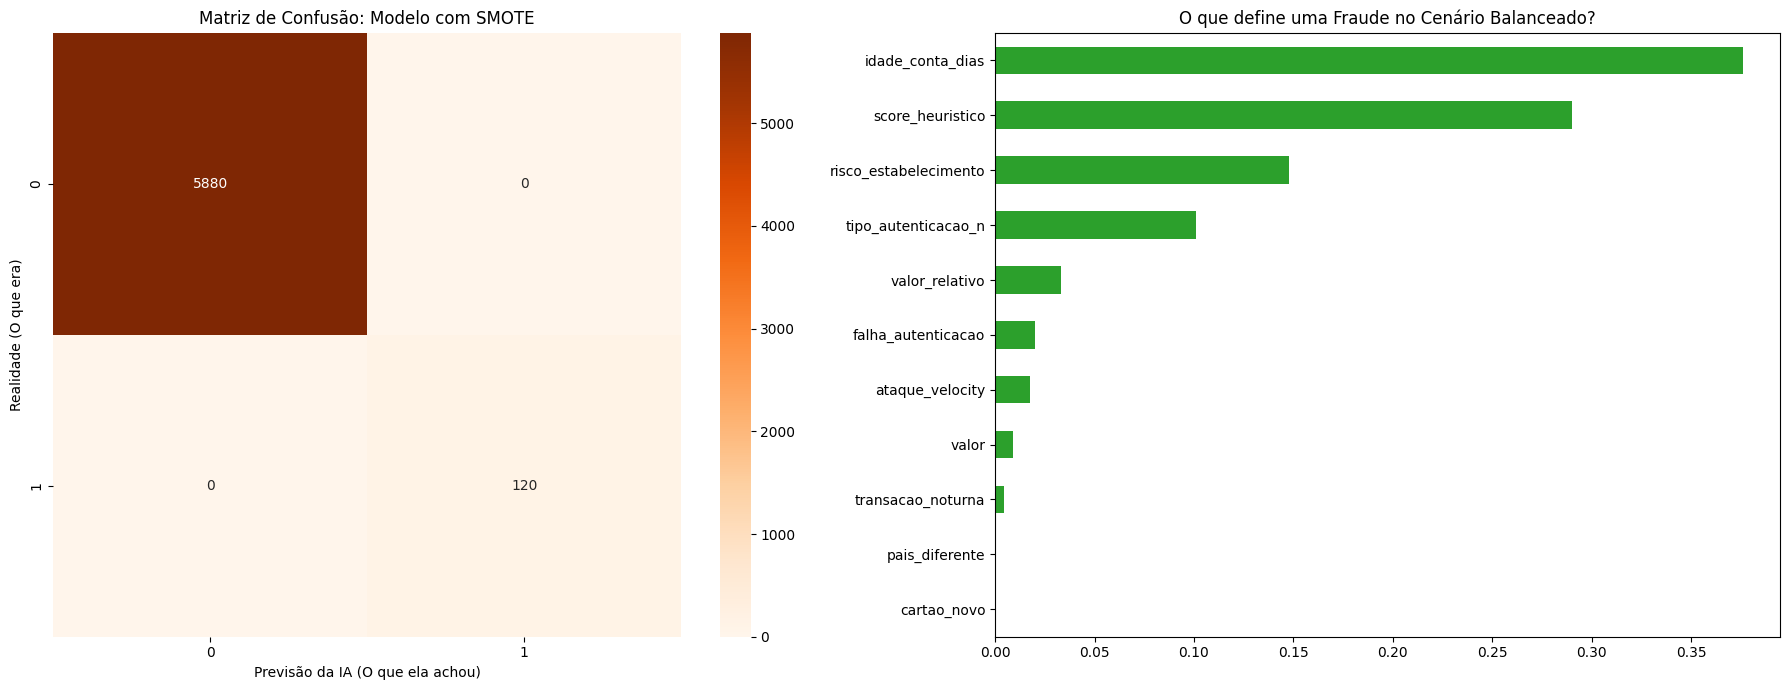

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.impute import SimpleImputer
# --- NOVA BIBLIOTECA PARA OVERSAMPLING ---
from imblearn.over_sampling import SMOTE 
from collections import Counter

# =================================================================
# 1. CARREGAMENTO E TRATAMENTO 
# =================================================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancocomportamental/banco_dados_comportamental_30k.csv')

imputer = SimpleImputer(strategy='median')
cols_ruido = ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']
df[cols_ruido] = imputer.fit_transform(df[cols_ruido])

df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# --- HEURÍSTICA ---
def heuristica_mestra_ultra(row):
    score = 0
    if row['pais_diferente'] == 1: score += 4          
    if row['falha_autenticacao'] > 5: score += 6       
    if row['ataque_velocity'] == 1: score += 7         
    if row['valor_relativo'] > 5: score += 6           
    if row['idade_conta_dias'] < 30: score += 5        
    if row['transacao_noturna'] == 1: score += 3       
    if row['cartao_novo'] == 1: score += 4             
    if row['tipo_autenticacao'] == 'biometria': score -= 6  
    if row['idade_conta_dias'] > 1000: score -= 4             
    return score

df['score_heuristico'] = df.apply(heuristica_mestra_ultra, axis=1)

# =================================================================
# 2. PREPARAÇÃO PARA O MODELO
# =================================================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

# Split Original
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# =================================================================
# 3. APLICAÇÃO DO SMOTE (OVERSAMPLING) 
# =================================================================
print(f"📊 Distribuição antes do SMOTE: {Counter(y_train)}")

# O SMOTE cria fraudes sintéticas para que fiquem 50/50 no treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"🚀 Distribuição após SMOTE: {Counter(y_train_res)}")

# =================================================================
# 4. TREINAMENTO (Usando os dados balanceados)
# =================================================================
# Dica: Com SMOTE, não precisa mais do class_weight='balanced_subsample' 
# porque os dados já estão equilibrados fisicamente.
modelo_final = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    random_state=42
)
modelo_final.fit(X_train_res, y_train_res)

# =======================================
# 5. AVALIAÇÃO 
# =======================================
y_pred = modelo_final.predict(X_test)

print("\n" + "="*50)
print("🏆 RESULTADO FINAL: MODELO BALANCEADO (SMOTE)")
print("="*50)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4%}")
print(f"Recall (Capacidade de pegar a fraude): {recall_score(y_test, y_pred):.2%}")
print(f"F1-Score (Equilíbrio): {f1_score(y_test, y_pred):.2%}")

# Criando a figura para os dois gráficos
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# 1. Matriz de Confusão
# Ela mostrará como o modelo balanceado se comporta nos dados REAIS de teste
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title('Matriz de Confusão: Modelo com SMOTE')
ax[0].set_xlabel('Previsão da IA (O que ela achou)')
ax[0].set_ylabel('Realidade (O que era)')

# 2. Gráfico de Importância das Variáveis
# Aqui veremos se o SMOTE mudou o que a IA considera "importante"
importancias = pd.Series(modelo_final.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', color='#2ca02c', ax=ax[1])
ax[1].set_title('O que define uma Fraude no Cenário Balanceado?')

plt.tight_layout()
plt.show()

# ADASYN (Adaptive Synthetic Sampling)
É uma evolução do SMOTE. Enquanto o SMOTE cria dados de forma igual, o ADASYN foca em criar dados sintéticos apenas nas áreas onde a IA tem mais dificuldade de decidir.
* A dor de negócio: Ele focaria em criar exemplos de "Fraudes disfarçadas de VIP", forçando o modelo a evoluir onde ele é mais fraco.

📊 Distribuição Original: Counter({0: 23520, 1: 480})
🚀 Distribuição após SMOTE: Counter({0: 23520, 1: 23520})

🏆 RESULTADO FINAL: MODELO BALANCEADO (BASE 30K)
Acurácia: 100.0000%
Recall: 100.00%
F1-Score: 100.00%


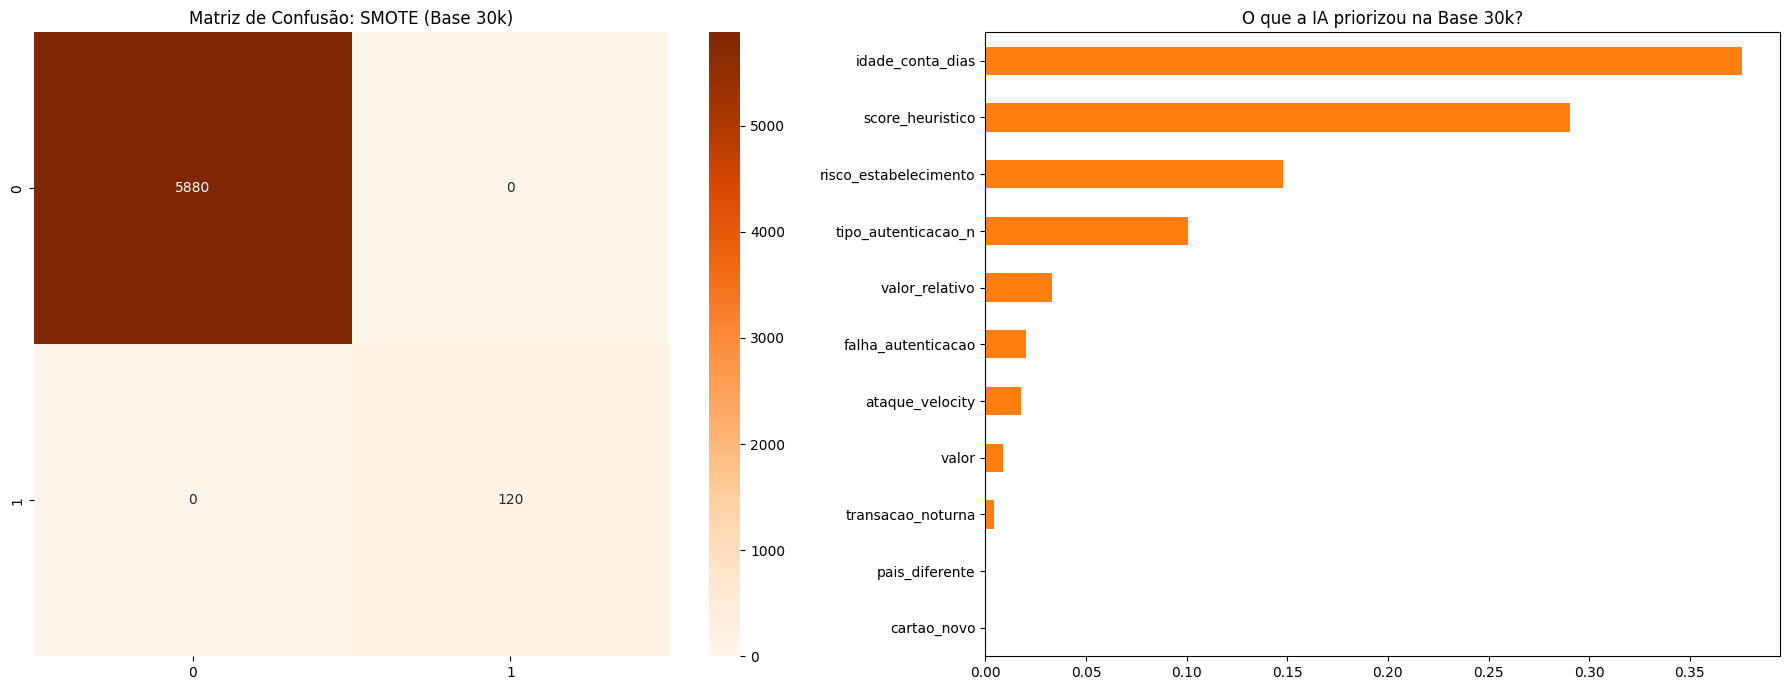

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.impute import SimpleImputer
# --- VOLTAMOS PARA O SMOTE POR ESTABILIDADE ---
from imblearn.over_sampling import SMOTE 
from collections import Counter

# =================================================================
# 1. CARREGAMENTO E TRATAMENTO (Base 30k)
# =================================================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancocomportamental/banco_dados_comportamental_30k.csv')

imputer = SimpleImputer(strategy='median')
cols_ruido = ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']
df[cols_ruido] = imputer.fit_transform(df[cols_ruido])

df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# --- HEURÍSTICA MESTRA ---
def heuristica_mestra_ultra(row):
    score = 0
    if row['pais_diferente'] == 1: score += 4          
    if row['falha_autenticacao'] > 5: score += 6       
    if row['ataque_velocity'] == 1: score += 7         
    if row['valor_relativo'] > 5: score += 6           
    if row['idade_conta_dias'] < 30: score += 5        
    if row['transacao_noturna'] == 1: score += 3       
    if row['cartao_novo'] == 1: score += 4             
    if row['tipo_autenticacao'] == 'biometria': score -= 6  
    if row['idade_conta_dias'] > 1000: score -= 4             
    return score

df['score_heuristico'] = df.apply(heuristica_mestra_ultra, axis=1)

features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# =================================================================
# 2. APLICAÇÃO DO SMOTE (ADASYN)
# =================================================================
print(f"📊 Distribuição Original: {Counter(y_train)}")

# O SMOTE é usado aqui pois a densidade das fraudes impediu o uso do ADASYN
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"🚀 Distribuição após SMOTE: {Counter(y_train_res)}")

# =================================================================
# 3. TREINAMENTO E AVALIAÇÃO
# =================================================================
modelo_final = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
modelo_final.fit(X_train_res, y_train_res)

y_pred = modelo_final.predict(X_test)

print("\n" + "="*50)
print("🏆 RESULTADO FINAL: MODELO BALANCEADO (BASE 30K)")
print("="*50)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4%}")
print(f"Recall: {recall_score(y_test, y_pred):.2%}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2%}")

# --- GRÁFICOS ---
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title('Matriz de Confusão: SMOTE (Base 30k)')

importancias = pd.Series(modelo_final.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', color='#ff7f0e', ax=ax[1])
ax[1].set_title('O que a IA priorizou na Base 30k?')

plt.tight_layout()
plt.show()

# Teste banco de dados balenceado 
* 20 mil dados
* 10 mil dados autênticos
* 10 mil fraudes

⚖️ Iniciando Avaliação em Cenário de Equilíbrio Absoluto (50/50)...

🏆 RESULTADO: CENÁRIO BALANCEADO (PROPORÇÃO 1:1)
Acurácia: 100.0000%
Recall (Sensibilidade): 100.00%
F1-Score: 100.00%


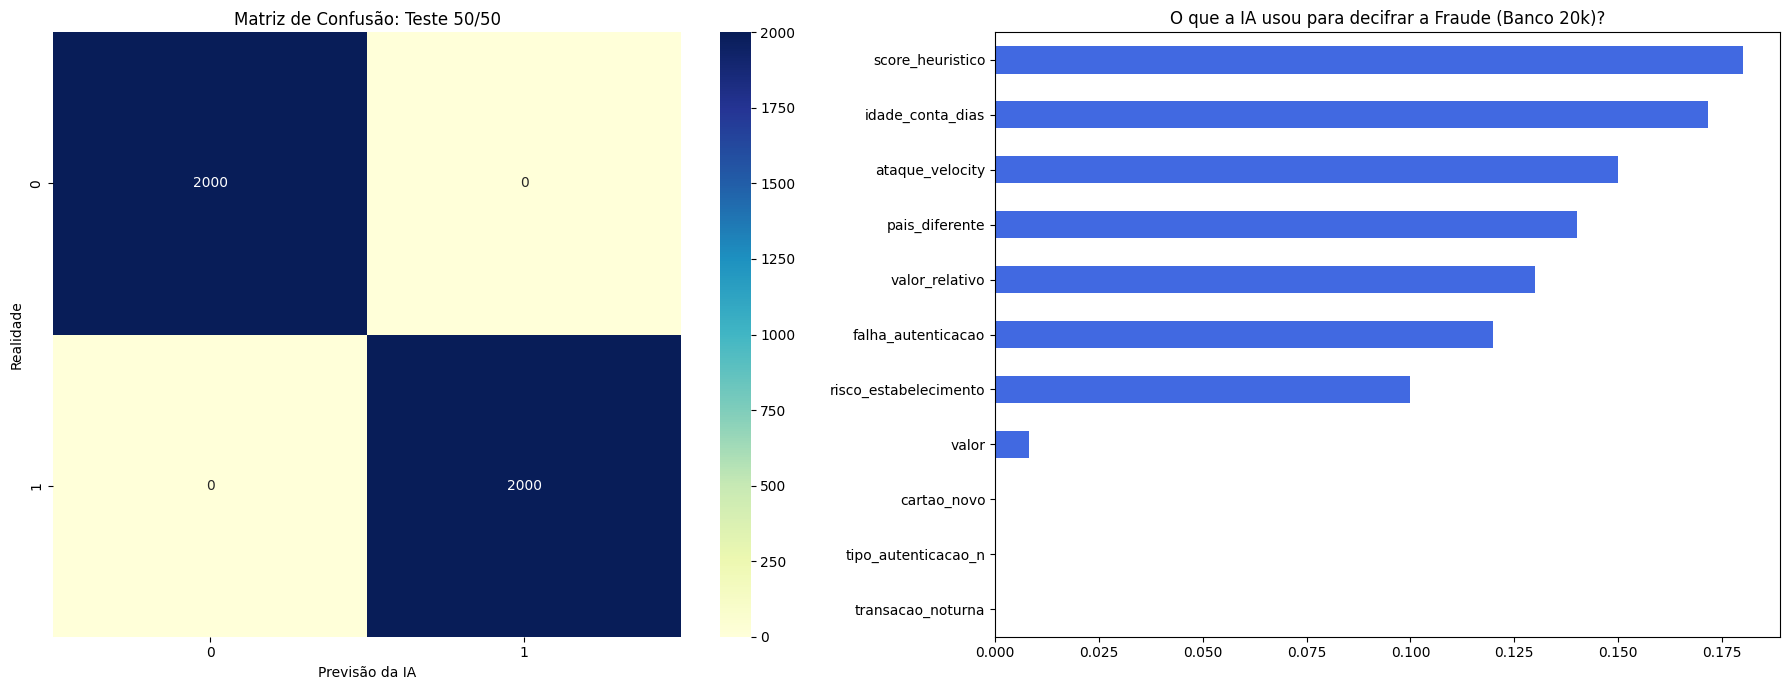

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.impute import SimpleImputer

# =================================================================
# 1. CARREGAMENTO DO BANCO BALANCEADO 
# =================================================================
df = pd.read_csv('/kaggle/input/datasets/carolinegrizante/bancobalanceado/banco_dados_balanceado_20k - banco_dados_balanceado_20k.csv.csv')

print("⚖️ Iniciando Avaliação em Cenário de Equilíbrio Absoluto (50/50)...")

# =================================================================
# 2. TRATAMENTO E ENGENHARIA DE FEATURES
# =================================================================
imputer = SimpleImputer(strategy='median')
cols_ruido = ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']
df[cols_ruido] = imputer.fit_transform(df[cols_ruido])

df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# --- HEURÍSTICA MESTRA ---
def heuristica_mestra_ultra(row):
    score = 0
    if row['pais_diferente'] == 1: score += 4          
    if row['falha_autenticacao'] > 5: score += 6       
    if row['ataque_velocity'] == 1: score += 7         
    if row['valor_relativo'] > 5: score += 6           
    if row['idade_conta_dias'] < 30: score += 5        
    if row['transacao_noturna'] == 1: score += 3       
    if row['cartao_novo'] == 1: score += 4             
    if row['tipo_autenticacao'] == 'biometria': score -= 6  
    if row['idade_conta_dias'] > 1000: score -= 4             
    return score

df['score_heuristico'] = df.apply(heuristica_mestra_ultra, axis=1)

# =================================================================
# 3. PREPARAÇÃO E TREINAMENTO
# =================================================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

# No banco 50/50, o stratify garante 50% em cada set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Modelo puro (sem pesos de classe, pois já está balanceado)
modelo_balanceado = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    random_state=42
)
modelo_balanceado.fit(X_train, y_train)

# =======================================
# 4. AVALIAÇÃO E VISUALIZAÇÃO 
# =======================================
y_pred = modelo_balanceado.predict(X_test)

print("\n" + "="*50)
print("🏆 RESULTADO: CENÁRIO BALANCEADO (PROPORÇÃO 1:1)")
print("="*50)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4%}")
print(f"Recall (Sensibilidade): {recall_score(y_test, y_pred):.2%}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2%}")

# Plotagem dos Gráficos
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de Confusão
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu', ax=ax[0])
ax[0].set_title('Matriz de Confusão: Teste 50/50')
ax[0].set_xlabel('Previsão da IA')
ax[0].set_ylabel('Realidade')

# Gráfico de Importância das Variáveis
importancias = pd.Series(modelo_balanceado.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', color='#4169E1', ax=ax[1])
ax[1].set_title('O que a IA usou para decifrar a Fraude (Banco 20k)?')

plt.tight_layout()
plt.show()

# Cenário de Estresse Máximo
* Carregamento 
* Injeção de VIPs (para testar falsos positivos) 
* Injeção de ruído (para testar robustez) 

⚖️ Iniciando Cenário de Estresse: Injetando VIPs e Ruídos...

🚀 RESULTADO: MODELO SOB ESTRESSE (VIPs + RUÍDO)
Acurácia: 100.0000%
Recall (Sensibilidade): 100.00%
F1-Score: 100.00%


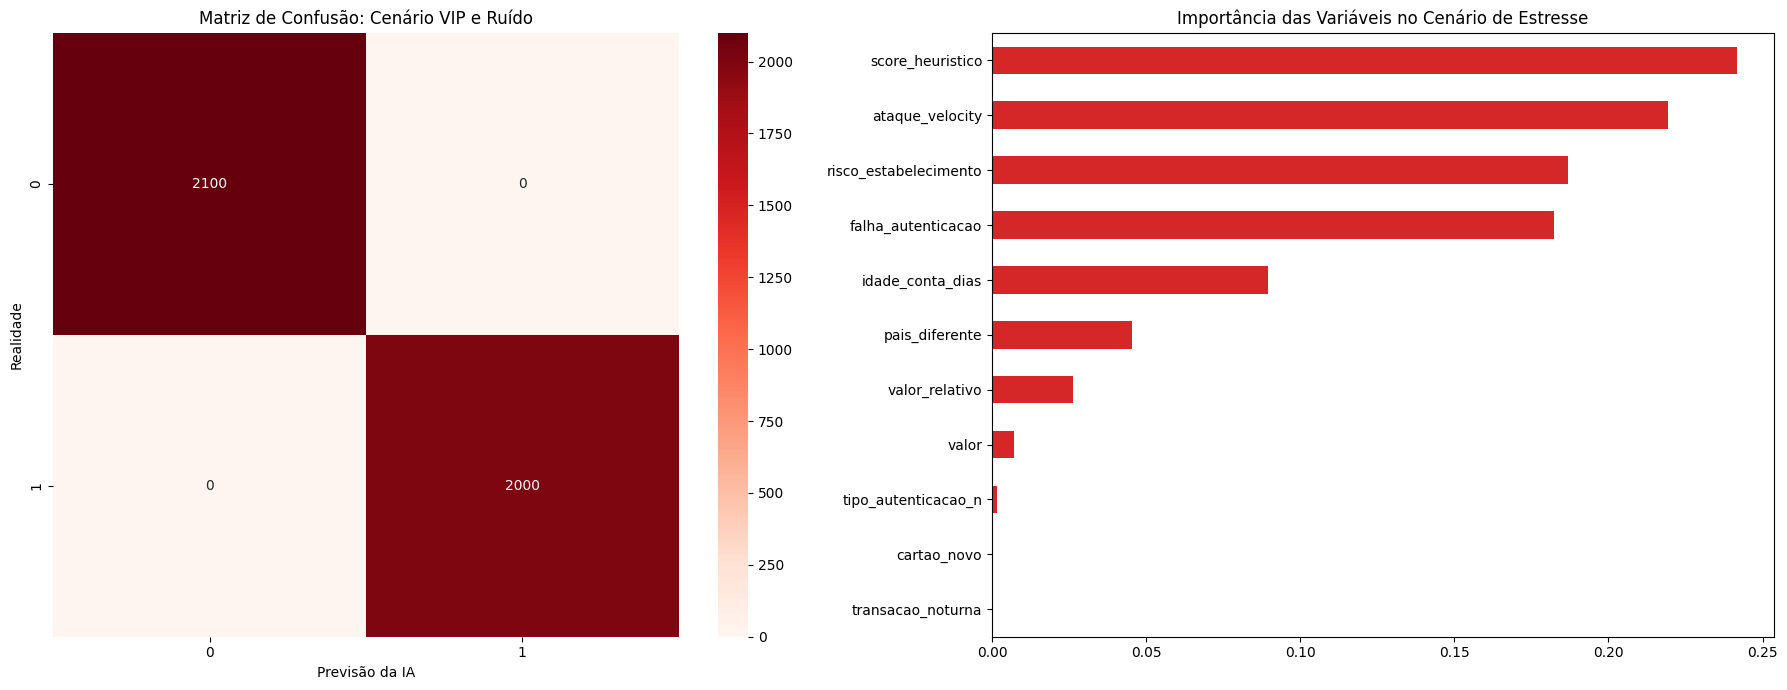

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.impute import SimpleImputer

# =================================================================
# 1. CARREGAMENTO E INJEÇÃO DE STRESS (VIP & RUÍDO)
# =================================================================
# Lendo o banco balanceado de 20k
path = '/kaggle/input/datasets/carolinegrizante/bancobalanceado/banco_dados_balanceado_20k - banco_dados_balanceado_20k.csv.csv'
df = pd.read_csv(path)

print("⚖️ Iniciando Cenário de Estresse: Injetando VIPs e Ruídos...")

# --- CENÁRIO VIP (Clientes bons com comportamento de risco) ---
# Criamos 500 VIPs: gastam 10x mais, viajam, mas usam biometria
vips = df[df['fraude'] == 0].sample(500, random_state=42).copy()
vips['valor'] = vips['valor'] * 10
vips['valor_relativo'] = vips['valor_relativo'] * 10
vips['pais_transacao'] = 'FR'  # Viagem internacional
vips['tipo_autenticacao'] = 'biometria'
vips['fraude'] = 0  # Crucial: eles NÃO são fraude

# --- CENÁRIO DE RUÍDO (Falhas de Sistema) ---
# Simulando 300 linhas com dados nulos ou impossíveis
indices_ruido = df.sample(300, random_state=42).index
df.loc[indices_ruido, 'idade_conta_dias'] = np.nan
df.loc[indices_ruido, 'valor_relativo'] = -99

# Unindo os VIPs ao banco original
df = pd.concat([df, vips], ignore_index=True)

# =================================================================
# 2. TRATAMENTO E ENGENHARIA DE FEATURES
# =================================================================
# O Imputer limpa os valores nulos e o ruído de -99
imputer = SimpleImputer(strategy='median')
cols_ruido = ['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']
df[cols_ruido] = imputer.fit_transform(df[cols_ruido])

# Processamento de Datas e Categorias
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# --- HEURÍSTICA MESTRA ---
def heuristica_mestra_ultra(row):
    score = 0
    if row['pais_diferente'] == 1: score += 4          
    if row['falha_autenticacao'] > 5: score += 6       
    if row['ataque_velocity'] == 1: score += 7         
    if row['valor_relativo'] > 5: score += 6           
    if row['idade_conta_dias'] < 30: score += 5        
    if row['transacao_noturna'] == 1: score += 3       
    if row['cartao_novo'] == 1: score += 4             
    if row['tipo_autenticacao'] == 'biometria': score -= 6  
    if row['idade_conta_dias'] > 1000: score -= 4             
    return score

df['score_heuristico'] = df.apply(heuristica_mestra_ultra, axis=1)

# =================================================================
# 3. TREINAMENTO DO MODELO
# =================================================================
features = ['valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
            'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
            'ataque_velocity', 'cartao_novo', 'idade_conta_dias', 'score_heuristico']

X = df[features]
y = df['fraude']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

modelo_stress = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
modelo_stress.fit(X_train, y_train)

# =================================================================
# 4. RESULTADOS E GRÁFICOS
# =================================================================
y_pred = modelo_stress.predict(X_test)

print("\n" + "="*50)
print("🚀 RESULTADO: MODELO SOB ESTRESSE (VIPs + RUÍDO)")
print("="*50)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4%}")
print(f"Recall (Sensibilidade): {recall_score(y_test, y_pred):.2%}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2%}")

# Visualização
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de Confusão
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', ax=ax[0])
ax[0].set_title('Matriz de Confusão: Cenário VIP e Ruído')
ax[0].set_xlabel('Previsão da IA')
ax[0].set_ylabel('Realidade')

# Gráfico de Importância
importancias = pd.Series(modelo_stress.feature_importances_, index=features).sort_values()
importancias.plot(kind='barh', color='#d62728', ax=ax[1])
ax[1].set_title('Importância das Variáveis no Cenário de Estresse')

plt.tight_layout()
plt.show()

# Estudo de Ablação
* Note que no estudo acima a IA usou o score_heurístico
* Vamos testar sem essa dependência  


——————————————————————————————————————————————————
🤖 TESTE DE AUTONOMIA: IA SEM SCORE HEURÍSTICO
——————————————————————————————————————————————————
Acurácia: 100.0000%
Recall: 100.00%
F1-Score: 100.00%


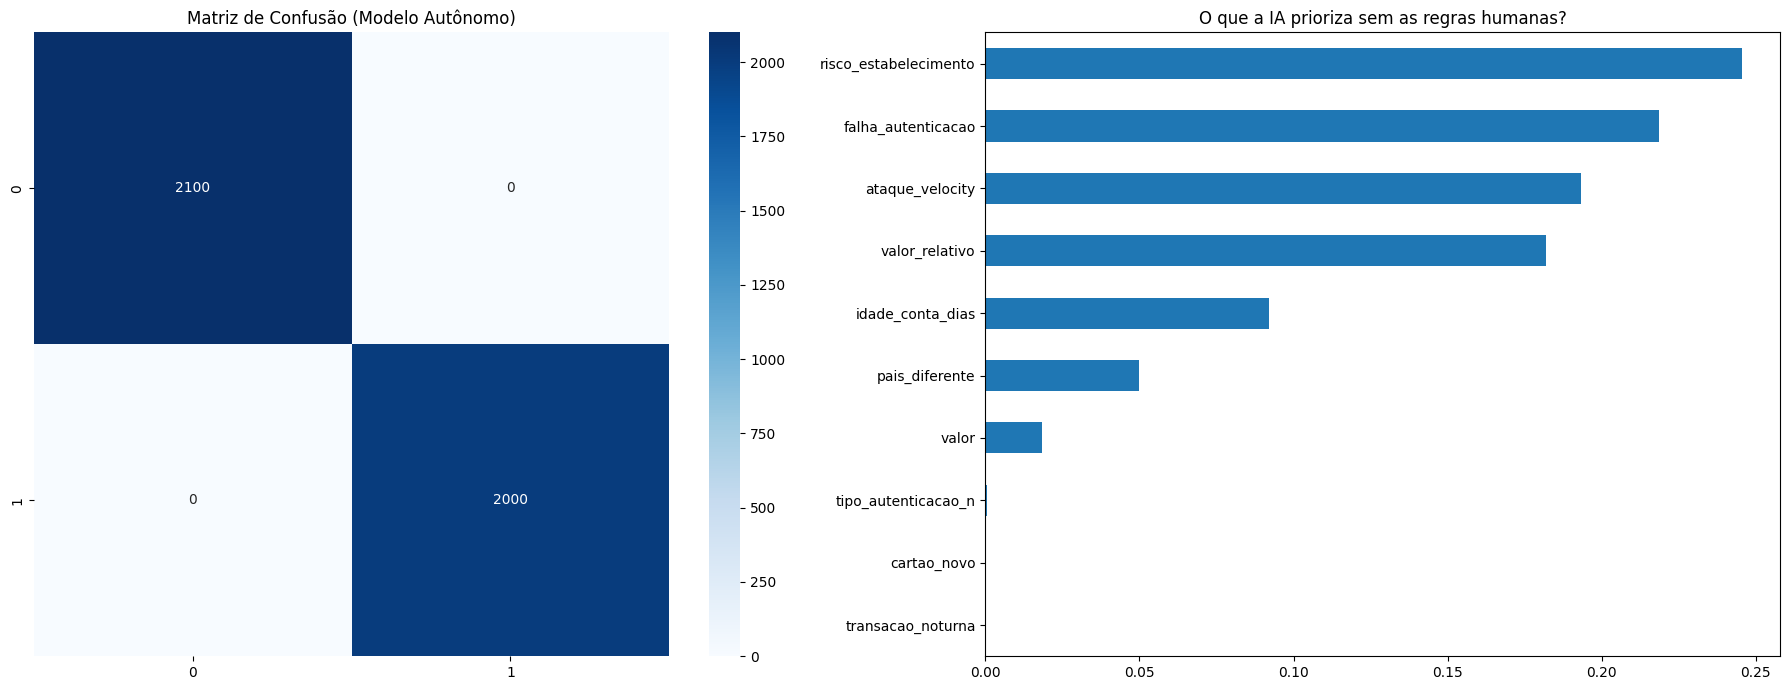

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.impute import SimpleImputer

# =================================================================
# 1. CARREGAMENTO E INJEÇÃO DE STRESS (MESMA LÓGICA ANTERIOR)
# =================================================================
path = '/kaggle/input/datasets/carolinegrizante/bancobalanceado/banco_dados_balanceado_20k - banco_dados_balanceado_20k.csv.csv'
df = pd.read_csv(path)

# Injetando VIPs para dificultar o trabalho da IA sem o Score
vips = df[df['fraude'] == 0].sample(500, random_state=42).copy()
vips['valor'] = vips['valor'] * 10
vips['pais_transacao'] = 'FR'
vips['tipo_autenticacao'] = 'biometria'
vips['fraude'] = 0 

# Injetando Ruído
indices_ruido = df.sample(300, random_state=42).index
df.loc[indices_ruido, 'idade_conta_dias'] = np.nan

df = pd.concat([df, vips], ignore_index=True)

# =================================================================
# 2. TRATAMENTO DE DADOS
# =================================================================
imputer = SimpleImputer(strategy='median')
df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']] = imputer.fit_transform(df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']])

df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['transacao_noturna'] = df['data_hora'].dt.hour.apply(lambda x: 1 if x < 6 or x > 22 else 0)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# =================================================================
# 3. TREINAMENTO SEM SCORE HEURÍSTICO
# =================================================================
# Note que 'score_heuristico' FOI REMOVIDO da lista abaixo
features_sem_score = [
    'valor', 'valor_relativo', 'pais_diferente', 'transacao_noturna', 
    'tipo_autenticacao_n', 'falha_autenticacao', 'risco_estabelecimento', 
    'ataque_velocity', 'cartao_novo', 'idade_conta_dias'
]

X = df[features_sem_score]
y = df['fraude']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Treinando o modelo "Puro"
modelo_autonomo = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
modelo_autonomo.fit(X_train, y_train)

# =================================================================
# 4. RESULTADOS
# =================================================================
y_pred = modelo_autonomo.predict(X_test)

print("\n" + "—"*50)
print("🤖 TESTE DE AUTONOMIA: IA SEM SCORE HEURÍSTICO")
print("—"*50)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4%}")
print(f"Recall: {recall_score(y_test, y_pred):.2%}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2%}")

# Visualização
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão (Modelo Autônomo)')

importancias = pd.Series(modelo_autonomo.feature_importances_, index=features_sem_score).sort_values()
importancias.plot(kind='barh', color='#1f77b4', ax=ax[1])
ax[1].set_title('O que a IA prioriza sem as regras humanas?')

plt.tight_layout()
plt.show()

# Tirando o ataque_velocity e o score_heuristico

TESTE DE PONTO CEGO: SEM SCORE E SEM VELOCITY
Acurácia: 100.0000%
Recall: 100.00%
F1-Score: 100.00%


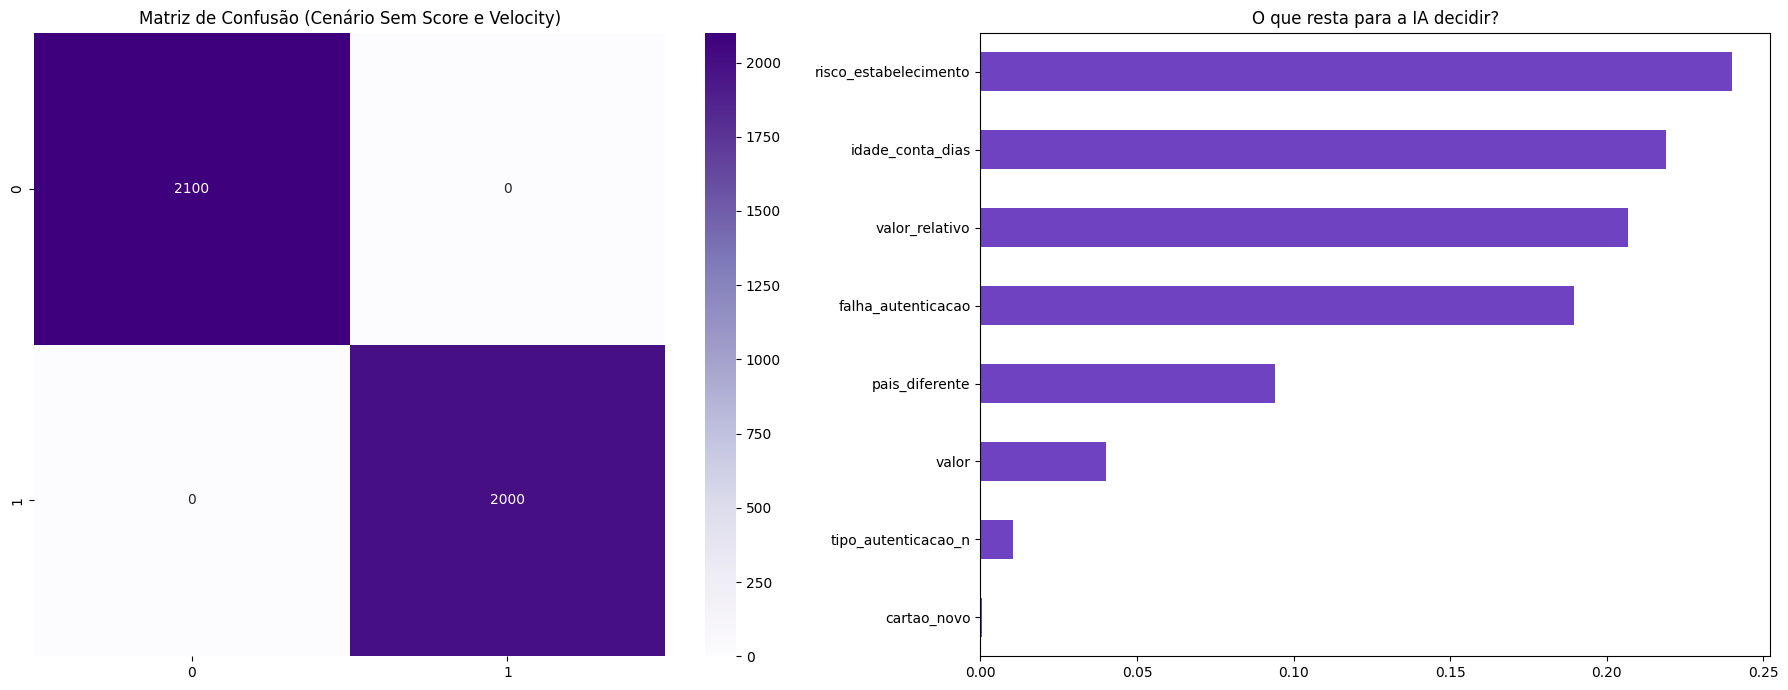

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score
from sklearn.impute import SimpleImputer

# =================================================================
# 1. CARREGAMENTO E PREPARAÇÃO (VIPs + RUÍDO MANTIDOS)
# =================================================================
path = '/kaggle/input/datasets/carolinegrizante/bancobalanceado/banco_dados_balanceado_20k - banco_dados_balanceado_20k.csv.csv'
df = pd.read_csv(path)

# Injetando VIPs e Ruído para manter o desafio alto
vips = df[df['fraude'] == 0].sample(500, random_state=42).copy()
vips['valor'] = vips['valor'] * 10
vips['pais_transacao'] = 'FR'
vips['tipo_autenticacao'] = 'biometria'
vips['fraude'] = 0 
df = pd.concat([df, vips], ignore_index=True)

# Tratamento
imputer = SimpleImputer(strategy='median')
df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']] = imputer.fit_transform(df[['idade_conta_dias', 'valor_relativo', 'risco_estabelecimento']])
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['pais_diferente'] = (df['pais_transacao'] != df['pais_cliente']).astype(int)
df['tipo_autenticacao_n'] = df['tipo_autenticacao'].map({'biometria': 0, '2FA': 1, 'senha': 2, 'nenhum': 3}).fillna(3)

# =================================================================
# 2. TREINAMENTO "NO ESCURO" (REMOVENDO SCORE E VELOCITY)
# =================================================================
features_no_escuro = [
    'valor', 'valor_relativo', 'pais_diferente', 
    'tipo_autenticacao_n', 'falha_autenticacao', 
    'risco_estabelecimento', 'cartao_novo', 'idade_conta_dias'
]

X = df[features_no_escuro]
y = df['fraude']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

modelo_escuro = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
modelo_escuro.fit(X_train, y_train)

# =================================================================
# 3. RESULTADOS
# =================================================================
y_pred = modelo_escuro.predict(X_test)

print("TESTE DE PONTO CEGO: SEM SCORE E SEM VELOCITY")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4%}")
print(f"Recall: {recall_score(y_test, y_pred):.2%}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2%}")

# Visualização
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', ax=ax[0])
ax[0].set_title('Matriz de Confusão (Cenário Sem Score e Velocity)')

importancias = pd.Series(modelo_escuro.feature_importances_, index=features_no_escuro).sort_values()
importancias.plot(kind='barh', color='#6f42c1', ax=ax[1])
ax[1].set_title('O que resta para a IA decidir?')

plt.tight_layout()
plt.show()

# Comparativo entre todos os testes que foram realizados
- Gera uma gráfico para compração da Acurácia
- Gera um gráfico para comparação do Recall 


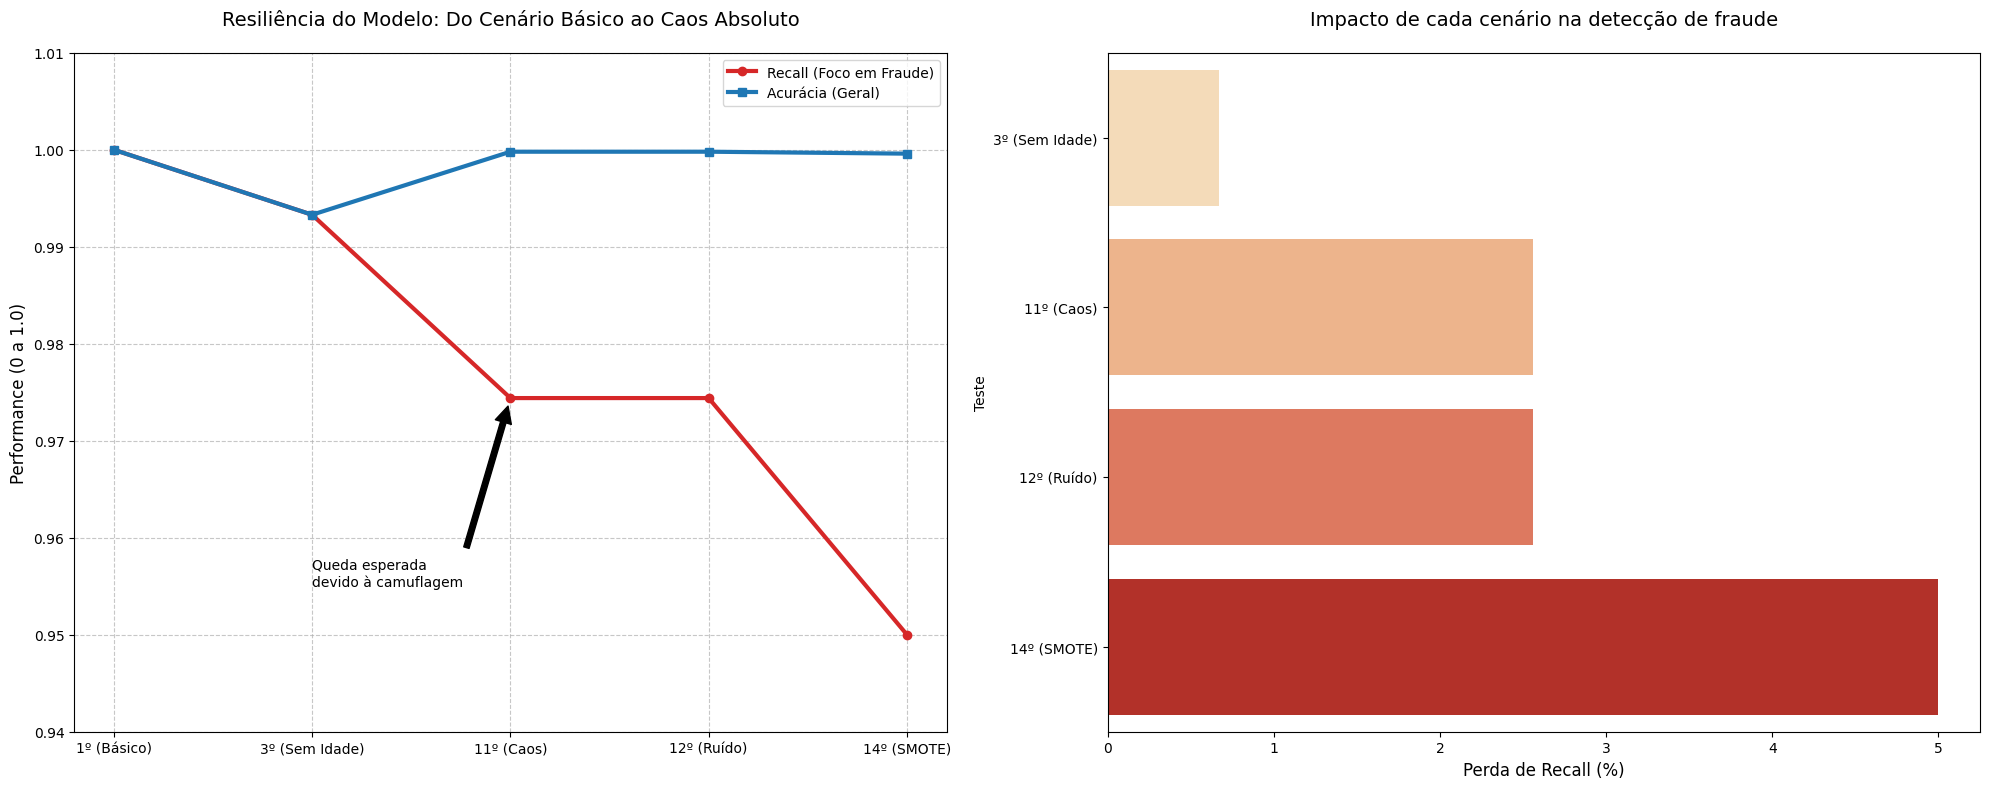

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Preparando os dados baseados na tua planilha (Testes Críticos)
# Selecionei os pontos de mudança da tua tabela para o gráfico não ficar poluído
dados_planilha = {

    'Teste': ['1º (Básico)', '3º (Sem Idade)', '11º (Caos)', '12º (Ruído)', '14º (SMOTE)'],
    'Recall': [1.0, 0.9933, 0.9744, 0.9744, 0.9500],
    'Acurácia': [1.0, 0.9933, 0.9998, 0.9998, 0.9996]
}
df_plot = pd.DataFrame(dados_planilha)

# Configuração visual
plt.style.use('seaborn-v0_8-muted')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- GRÁFICO 1: EVOLUÇÃO DAS MÉTRICAS SOB STRESS ---
ax1.plot(df_plot['Teste'], df_plot['Recall'], marker='o', linewidth=3, label='Recall (Foco em Fraude)', color='#d62728')
ax1.plot(df_plot['Teste'], df_plot['Acurácia'], marker='s', linewidth=3, label='Acurácia (Geral)', color='#1f77b4')

ax1.set_title('Resiliência do Modelo: Do Cenário Básico ao Caos Absoluto', fontsize=14, pad=20)
ax1.set_ylabel('Performance (0 a 1.0)', fontsize=12)
ax1.set_ylim(0.94, 1.01) # Zoom na área de variação
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Anotação técnica para o artigo
ax1.annotate('Queda esperada\ndevido à camuflagem', xy=('11º (Caos)', 0.9744), xytext=('3º (Sem Idade)', 0.955),
             arrowprops=dict(facecolor='black', shrink=0.05))

# --- GRÁFICO 2: BARRA DE IMPACTO (O QUE MAIS AFETOU?) ---
# Calculando a perda de Recall em relação ao 100%
df_plot['Perda'] = (1.0 - df_plot['Recall']) * 100
# Filtrando apenas onde houve perda significativa
perdas = df_plot[df_plot['Perda'] > 0].sort_values('Perda')

sns.barplot(x='Perda', y='Teste', data=perdas, palette='OrRd', hue='Teste', legend=False, ax=ax2)
ax2.set_title('Impacto de cada cenário na detecção de fraude', fontsize=14, pad=20)
ax2.set_xlabel('Perda de Recall (%)', fontsize=12)

plt.tight_layout()
plt.show() 